In [1]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

nome_arquivo = next(iter(uploaded))
conteudo = uploaded[nome_arquivo]

excel = pd.ExcelFile(io.BytesIO(conteudo))

print("Arquivo carregado:", nome_arquivo)
print("Abas encontradas:")

for aba in excel.sheet_names:
    print("-", aba)

Saving Livros na Estante.xlsx to Livros na Estante.xlsx
Arquivo carregado: Livros na Estante.xlsx
Abas encontradas:
- Livros na Estante
- Lidos
- Estatisticas de Leitura
- Ano compra
- Autores
- Editora
- Lidos Ano
- Séries Incompletas


In [2]:
# Carregar todas as abas da planilha

abas = {
    aba: pd.read_excel(io.BytesIO(conteudo), sheet_name=aba)
    for aba in excel.sheet_names
}

# Criar um resumo da estrutura de cada aba

resumo_abas = []

for nome_aba, dataframe in abas.items():
    resumo_abas.append({
        "Aba": nome_aba,
        "Quantidade de linhas": dataframe.shape[0],
        "Quantidade de colunas": dataframe.shape[1],
        "Colunas encontradas": " | ".join(map(str, dataframe.columns))
    })

resumo_abas_df = pd.DataFrame(resumo_abas)

display(resumo_abas_df)

,Aba,Quantidade de linhas,Quantidade de colunas,Colunas encontradas
0,Livros na Estante,325,6,Nome | Autor | Editora | ISBN | Ano-Compra | Lido
1,Lidos,524,5,Nome | Autor | Data de Leitura | Status na Est...
2,Estatisticas de Leitura,26,3,Status de Leitura | Quantidade | Unnamed: 2
3,Ano compra,13,2,Unnamed: 0 | Unnamed: 1
4,Autores,160,2,Unnamed: 0 | Unnamed: 1
5,Editora,50,2,Unnamed: 0 | Unnamed: 1
6,Lidos Ano,29,2,Unnamed: 0 | Unnamed: 1
7,Séries Incompletas,13,1,Nome


In [3]:
# Selecionar a base principal

livros = abas["Livros na Estante"].copy()

print("Quantidade de registros:", livros.shape[0])
print("Quantidade de colunas:", livros.shape[1])

print("\nTipos de dados:")
display(livros.dtypes.to_frame("Tipo"))

print("\nPrimeiros registros:")
display(livros.head(10))

print("\nValores ausentes:")
ausentes = pd.DataFrame({
    "Coluna": livros.columns,
    "Quantidade de vazios": livros.isna().sum().values,
    "Percentual de vazios": (livros.isna().mean().values * 100).round(2)
})

display(ausentes)

Quantidade de registros: 325
Quantidade de colunas: 6

Tipos de dados:


,Tipo
Nome,object
Autor,object
Editora,object
ISBN,object
Ano-Compra,float64
Lido,object



Primeiros registros:


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido
0,1984,George Orwell,Clube de Literatura Clássica,NaN,2023.0,Sim
1,Coração das Trevas,Joseph Conrad,Clube de Literatura Clássica,NaN,2023.0,Abandonado
2,Contos do Grotesco e do Arabesco,Edgar Allan Poe,Clube de Literatura Clássica,NaN,2023.0,Abandonado
3,Don Juan,Lord Byron,Clube de Literatura Clássica,978-658-7036-75-5,2023.0,Não
4,O Finado Mattia Pascal,Luigi Pirandello,Clube de Literatura Clássica,978-65-87036-76-2,2023.0,Não
5,A Conciência de Zeno,Italo Svevo,Clube de Literatura Clássica,NaN,2023.0,Não
6,Fábulas de Esopo,Esopo,Clube de Literatura Clássica,978-65-87036-88-5,2023.0,Não
7,Ilusões Perdidas,Honoré de Balzac,Clube de Literatura Clássica,978-65-87036-74-8,2023.0,Não
8,Jerusalem Libertada,Torquato Tasso,Clube de Literatura Clássica,978-65-87036-33-5,2023.0,Não
9,Saga de Njall,Anônimo,Clube de Literatura Clássica,NaN,2023.0,Não



Valores ausentes:


,Coluna,Quantidade de vazios,Percentual de vazios
0,Nome,0,0.00
1,Autor,0,0.00
2,Editora,93,28.62
3,ISBN,298,91.69
4,Ano-Compra,149,45.85
5,Lido,0,0.00


In [4]:
# Verificar categorias, duplicidades e frequências

print("Categorias da coluna Lido:")
status_lido = (
    livros["Lido"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

display(status_lido)

print("\nDuplicidades exatas:")
duplicados_exatos = livros[livros.duplicated(keep=False)]
print("Quantidade:", len(duplicados_exatos))
display(duplicados_exatos)

print("\nPossíveis duplicidades por Nome e Autor:")
duplicados_nome_autor = livros[
    livros.duplicated(subset=["Nome", "Autor"], keep=False)
].sort_values(["Nome", "Autor"])

print("Quantidade:", len(duplicados_nome_autor))
display(duplicados_nome_autor)

print("\nEditoras mais frequentes:")
editoras = (
    livros["Editora"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("Editora")
    .reset_index(name="Quantidade")
)

display(editoras.head(30))

print("\nAutores mais frequentes:")
autores = (
    livros["Autor"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("Autor")
    .reset_index(name="Quantidade")
)

display(autores.head(30))

Categorias da coluna Lido:


,Status,Quantidade
0,Não,189
1,Sim,120
2,Abandonado,13
3,Lendo,2
4,Relendo,1



Duplicidades exatas:
Quantidade: 0


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido



Possíveis duplicidades por Nome e Autor:
Quantidade: 0


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido



Editoras mais frequentes:


,Editora,Quantidade
0,<NA>,93
1,Clube de Literatura Clássica,37
2,Intrinseca,30
3,Seguinte,16
4,Harper Collins,16
5,Rocco,12
6,Galera,11
7,Principis,10
8,Record,8
9,Darkside,8



Autores mais frequentes:


,Autor,Quantidade
0,J. K. Rowling,18
1,J. R. R. Tolkien,17
2,Lemony Snicket,13
3,Anônimo,10
4,Rick Riordan,10
5,Roger Zelazny,10
6,Agatha Christie,7
7,Justin Somper,6
8,R. F. Kuang,5
9,Graciliano Ramos,5


In [5]:
# Auditoria da coluna Ano-Compra

print("Resumo estatístico de Ano-Compra:")
display(livros["Ano-Compra"].describe())

print("\nValores de Ano-Compra:")
anos = (
    livros["Ano-Compra"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Ano-Compra")
    .reset_index(name="Quantidade")
)

display(anos)

print("\nAnos potencialmente inválidos:")
anos_invalidos = livros[
    livros["Ano-Compra"].notna()
    & (
        (livros["Ano-Compra"] < 1900)
        | (livros["Ano-Compra"] > 2026)
        | (livros["Ano-Compra"] % 1 != 0)
    )
]

display(anos_invalidos)

Resumo estatístico de Ano-Compra:


,Ano-Compra
count,176.000000
mean,2023.846591
std,2.597645
min,2015.000000
25%,2023.000000
50%,2025.000000
75%,2026.000000
max,2026.000000



Valores de Ano-Compra:


,Ano-Compra,Quantidade
0,2015.0,3
1,2018.0,10
2,2019.0,2
3,2020.0,8
4,2022.0,10
5,2023.0,45
6,2024.0,7
7,2025.0,15
8,2026.0,76
9,NaN,149



Anos potencialmente inválidos:


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido


In [6]:
import re
import unicodedata

# Auditoria da coluna ISBN

def limpar_isbn(valor):
    if pd.isna(valor):
        return pd.NA
    return re.sub(r"[^0-9Xx]", "", str(valor)).upper()

isbn_limpo = livros["ISBN"].apply(limpar_isbn)

isbn_auditoria = pd.DataFrame({
    "ISBN original": livros["ISBN"],
    "ISBN limpo": isbn_limpo,
    "Quantidade de caracteres": isbn_limpo.str.len()
})

print("Resumo dos tamanhos de ISBN:")
display(
    isbn_auditoria["Quantidade de caracteres"]
    .value_counts(dropna=False)
    .rename_axis("Tamanho")
    .reset_index(name="Quantidade")
)

print("\nISBNs preenchidos com tamanho diferente de 10 ou 13:")
isbn_invalidos = isbn_auditoria[
    isbn_auditoria["ISBN limpo"].notna()
    & ~isbn_auditoria["Quantidade de caracteres"].isin([10, 13])
]

display(isbn_invalidos)

print("\nISBNs repetidos:")
isbn_repetidos = livros.assign(ISBN_limpo=isbn_limpo)

isbn_repetidos = isbn_repetidos[
    isbn_repetidos["ISBN_limpo"].notna()
    & isbn_repetidos.duplicated("ISBN_limpo", keep=False)
].sort_values("ISBN_limpo")

display(isbn_repetidos)

Resumo dos tamanhos de ISBN:


,Tamanho,Quantidade
0,<NA>,298
1,13,25
2,0,1
3,10,1



ISBNs preenchidos com tamanho diferente de 10 ou 13:


,ISBN original,ISBN limpo,Quantidade de caracteres
60,sem registro,,0



ISBNs repetidos:


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido,ISBN_limpo
253,Turma da Onça Pintada - Romeu foi Clonado?,Anônimo,Oca,978-65-86962-09-3,NaN,Sim,9786586962093
254,Turma da Onça Pintada - Uma Nova Amizade,Anônimo,Oca,978-65-86962-09-3,NaN,Sim,9786586962093
252,Turma da Onça Pintada - Cadê o Rodolfo?,Anônimo,Oca,978-65-86962-10-9,NaN,Sim,9786586962109
255,Turma da Onça Pintada - A grande corrida,Anônimo,Oca,978-65-86962-10-9,NaN,Sim,9786586962109
256,Turma da Onça Pintada - Festa na Floresta,Anônimo,Oca,978-65-86962-10-9,NaN,Sim,9786586962109


In [7]:
import unicodedata
import re

def normalizar_texto(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )
    texto = re.sub(r"\s+", " ", texto)

    return texto

def encontrar_variacoes(dataframe, coluna):
    temp = dataframe[[coluna]].dropna().copy()
    temp["Normalizado"] = temp[coluna].apply(normalizar_texto)

    grupos = (
        temp.groupby("Normalizado")[coluna]
        .agg(lambda valores: sorted(set(valores.astype(str))))
        .reset_index(name="Variações encontradas")
    )

    grupos["Quantidade de variações"] = (
        grupos["Variações encontradas"].str.len()
    )

    return grupos[
        grupos["Quantidade de variações"] > 1
    ]

print("Possíveis variações de grafia em Autor:")
display(encontrar_variacoes(livros, "Autor"))

print("\nPossíveis variações de grafia em Editora:")
display(encontrar_variacoes(livros, "Editora"))

print("\nPossíveis variações de grafia em Lido:")
display(encontrar_variacoes(livros, "Lido"))

Possíveis variações de grafia em Autor:


,Normalizado,Variações encontradas,Quantidade de variações



Possíveis variações de grafia em Editora:


,Normalizado,Variações encontradas,Quantidade de variações
7,companhia das letras,"[Companhia das Letras, Companhia das Letras ]",2



Possíveis variações de grafia em Lido:


,Normalizado,Variações encontradas,Quantidade de variações


In [8]:
# Visualizar estrutura e primeiros registros de todas as abas

for nome_aba, dataframe in abas.items():
    print("\n" + "=" * 60)
    print("ABA:", nome_aba)
    print("Linhas:", dataframe.shape[0])
    print("Colunas:", dataframe.shape[1])
    print("Nomes das colunas:", list(dataframe.columns))
    display(dataframe.head(10))


ABA: Livros na Estante
Linhas: 325
Colunas: 6
Nomes das colunas: ['Nome', 'Autor', 'Editora', 'ISBN', 'Ano-Compra', 'Lido']


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido
0,1984,George Orwell,Clube de Literatura Clássica,NaN,2023.0,Sim
1,Coração das Trevas,Joseph Conrad,Clube de Literatura Clássica,NaN,2023.0,Abandonado
2,Contos do Grotesco e do Arabesco,Edgar Allan Poe,Clube de Literatura Clássica,NaN,2023.0,Abandonado
3,Don Juan,Lord Byron,Clube de Literatura Clássica,978-658-7036-75-5,2023.0,Não
4,O Finado Mattia Pascal,Luigi Pirandello,Clube de Literatura Clássica,978-65-87036-76-2,2023.0,Não
5,A Conciência de Zeno,Italo Svevo,Clube de Literatura Clássica,NaN,2023.0,Não
6,Fábulas de Esopo,Esopo,Clube de Literatura Clássica,978-65-87036-88-5,2023.0,Não
7,Ilusões Perdidas,Honoré de Balzac,Clube de Literatura Clássica,978-65-87036-74-8,2023.0,Não
8,Jerusalem Libertada,Torquato Tasso,Clube de Literatura Clássica,978-65-87036-33-5,2023.0,Não
9,Saga de Njall,Anônimo,Clube de Literatura Clássica,NaN,2023.0,Não



ABA: Lidos
Linhas: 524
Colunas: 5
Nomes das colunas: ['Nome', 'Autor', 'Data de Leitura', 'Status na Estante', 'Coluna1']


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
0,"Merlin, o Mágico",Anônimo,1998-01-01,Sumiu,NaN
1,Patolino,NaN,1998-01-01,Sumiu,NaN
2,A Princesa e a Ervilha,Sérgio Luiz de Oliveira Silva,1999-01-01,Sumiu,NaN
3,Mini Livro Jó,NaN,1999-01-01,Sumiu,NaN
4,Mini Livro Pastor,NaN,1999-01-01,Sumiu,NaN
5,"Bisa Bia, Bisa Bel",Ana Maria Machado,2002-01-01,Sumiu,NaN
6,Contos de Fadas Capa vermelha,NaN,2002-01-01,Sumiu,NaN
7,"Carta errante, avó atrapalhada, menina anivers...",Mirna Pinsky,2002-04-01,Estante,NaN
8,Harry Potter e a Pedra Filosofal,J. K. Rowling,2004-01-01,Emprestado,Plínio
9,Harry Potter e a Câmara Secreta,J. K. Rowling,2004-01-01,Emprestado,Plínio



ABA: Estatisticas de Leitura
Linhas: 26
Colunas: 3
Nomes das colunas: ['Status de Leitura', 'Quantidade', 'Unnamed: 2']


...

,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,Rótulos de Linha,Contagem de Nome
2,Alfaguara,2
3,Argumento,1
4,Arqueiro,4
5,Bertrand Brasil,2
6,Biblioteca Azul,5
7,Clube de Literatura Clássica,37
8,Companhia das Letras,4
9,Companhia das Letras,2



ABA: Lidos Ano
Linhas: 29
Colunas: 2
Nomes das colunas: ['Unnamed: 0', 'Unnamed: 1']


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,Rótulos de Linha,Contagem de Data de Leitura
2,<01/01/1998,NaN
3,1998,2
4,1999,3
5,2002,3
6,2004,2
7,2005,3
8,2006,2
9,2007,5



ABA: Séries Incompletas
Linhas: 13
Colunas: 1
Nomes das colunas: ['Nome']


,Nome
0,NaN
1,Fronteiras do universo
2,Nana
3,Mundo de tinta
4,Jogos Vorazes
5,Herois do Olimpo
6,Millenium
7,Ciclo de Avalon
8,Rangers
9,As cronicas de Anne


In [9]:
lidos = abas["Lidos"].copy()

print("Linhas lidas pelo pandas:", len(lidos))
print("Linhas com Nome preenchido:", lidos["Nome"].notna().sum())
print("Linhas totalmente vazias:", lidos.isna().all(axis=1).sum())
print("Última linha com Nome preenchido:", lidos["Nome"].last_valid_index())

display(lidos.tail(20))

Linhas lidas pelo pandas: 524
Linhas com Nome preenchido: 275
Linhas totalmente vazias: 0
Última linha com Nome preenchido: 274


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
504,NaN,NaN,NaT,Sim,NaN
505,NaN,NaN,NaT,Sim,NaN
506,NaN,NaN,NaT,Sim,NaN
507,NaN,NaN,NaT,Sim,NaN
508,NaN,NaN,NaT,Sim,NaN
509,NaN,NaN,NaT,Sim,NaN
510,NaN,NaN,NaT,Sim,NaN
511,NaN,NaN,NaT,Sim,NaN
512,NaN,NaN,NaT,Sim,NaN
513,NaN,NaN,NaT,Sim,NaN


In [10]:
# Manter apenas registros reais da aba Lidos

lidos_validos = lidos[
    lidos["Nome"].notna()
].copy()

print("Registros válidos:", len(lidos_validos))
print("Linhas residuais removidas:", len(lidos) - len(lidos_validos))

display(lidos_validos.tail())

Registros válidos: 275
Linhas residuais removidas: 249


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
270,Caninos Brancos,Jack London,2026-06-04,Estante,Audible
271,O Garoto do Riquixá,Lao She,2026-06-11,Estante,NaN
272,As aventuras de Pedro Coelho,Beatrix Potter,2026-07-06,Estante,NaN
273,Terra-média - Beren e Luthien,J. R. R. Tolkien,2026-07-10,Estante,NaN
274,As Minas do Rei Salomão,Henry Rider Haggard,NaT,Biblioteca,Audible


In [11]:
print("Quantidade de registros válidos:", len(lidos_validos))

print("\nTipos de dados:")
display(lidos_validos.dtypes.to_frame("Tipo"))

print("\nValores ausentes:")
ausentes_lidos = pd.DataFrame({
    "Coluna": lidos_validos.columns,
    "Quantidade de vazios": lidos_validos.isna().sum().values,
    "Percentual de vazios": (
        lidos_validos.isna().mean().values * 100
    ).round(2)
})

display(ausentes_lidos)

print("\nCategorias de Status na Estante:")
display(
    lidos_validos["Status na Estante"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

print("\nPeríodo das datas de leitura:")
print("Data mínima:", lidos_validos["Data de Leitura"].min())
print("Data máxima:", lidos_validos["Data de Leitura"].max())

print("\nDuplicidades exatas:")
duplicados_lidos = lidos_validos[
    lidos_validos.duplicated(keep=False)
]

print("Quantidade:", len(duplicados_lidos))
display(duplicados_lidos)

print("\nPossíveis repetições do mesmo livro na mesma data:")
repeticoes_leitura = lidos_validos[
    lidos_validos.duplicated(
        subset=["Nome", "Autor", "Data de Leitura"],
        keep=False
    )
].sort_values(["Nome", "Data de Leitura"])

print("Quantidade:", len(repeticoes_leitura))
display(repeticoes_leitura)

Quantidade de registros válidos: 275

Tipos de dados:


,Tipo
Nome,object
Autor,object
Data de Leitura,datetime64[ns]
Status na Estante,object
Coluna1,object



Valores ausentes:


,Coluna,Quantidade de vazios,Percentual de vazios
0,Nome,0,0.00
1,Autor,4,1.45
2,Data de Leitura,1,0.36
3,Status na Estante,0,0.00
4,Coluna1,145,52.73



Categorias de Status na Estante:


,Status,Quantidade
0,Estante,109
1,Emprestado,68
2,Biblioteca,61
3,Doado,14
4,A venda,11
5,Sumiu,10
6,Vendido,2



Período das datas de leitura:
Data mínima: 1998-01-01 00:00:00
Data máxima: 2026-07-10 00:00:00

Duplicidades exatas:
Quantidade: 0


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1



Possíveis repetições do mesmo livro na mesma data:
Quantidade: 0


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1


In [12]:
print("Registros com Autor ausente:")
display(
    lidos_validos[
        lidos_validos["Autor"].isna()
    ]
)

print("\nRegistro com Data de Leitura ausente:")
display(
    lidos_validos[
        lidos_validos["Data de Leitura"].isna()
    ]
)

print("\nValores preenchidos em Coluna1:")
display(
    lidos_validos[
        lidos_validos["Coluna1"].notna()
    ][["Nome", "Status na Estante", "Coluna1"]].head(50)
)

Registros com Autor ausente:


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
1,Patolino,NaN,1998-01-01,Sumiu,NaN
3,Mini Livro Jó,NaN,1999-01-01,Sumiu,NaN
4,Mini Livro Pastor,NaN,1999-01-01,Sumiu,NaN
6,Contos de Fadas Capa vermelha,NaN,2002-01-01,Sumiu,NaN



Registro com Data de Leitura ausente:


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
274,As Minas do Rei Salomão,Henry Rider Haggard,NaT,Biblioteca,Audible



Valores preenchidos em Coluna1:


,Nome,Status na Estante,Coluna1
8,Harry Potter e a Pedra Filosofal,Emprestado,Plínio
9,Harry Potter e a Câmara Secreta,Emprestado,Plínio
11,Harry Potter e o Prisioneiro de Azkaban,Emprestado,Plínio
12,Brida,Emprestado,Larissa
13,Ciclo de Avalon - As Brumas de Avalon - A Senh...,Emprestado,Larissa
14,Ciclo de Avalon - As Brumas de Avalon - A Gran...,Emprestado,Larissa
15,Harry Potter e o Cálice de Fogo,Emprestado,Plínio
16,Harry Potter e a Ordem da Fênix,Emprestado,Plínio
17,Harry Potter e o Enigma do Príncipe,Emprestado,Plínio
18,Ciclo de Avalon - As Brumas de Avalon - O Pris...,Emprestado,Larissa


In [13]:
# Uso da coluna complementar por status

uso_detalhe = (
    lidos_validos[lidos_validos["Coluna1"].notna()]
    .groupby(["Status na Estante", "Coluna1"])
    .size()
    .reset_index(name="Quantidade")
    .sort_values(
        ["Status na Estante", "Quantidade"],
        ascending=[True, False]
    )
)

display(uso_detalhe)

print("\nQuantidade de detalhes preenchidos por status:")
display(
    lidos_validos.assign(
        Detalhe_preenchido=lidos_validos["Coluna1"].notna()
    )
    .groupby("Status na Estante")["Detalhe_preenchido"]
    .agg(["sum", "count"])
    .rename(columns={
        "sum": "Com detalhe",
        "count": "Total"
    })
)

,Status na Estante,Coluna1,Quantidade
0,Biblioteca,Audible,24
4,Biblioteca,Kindle,19
2,Biblioteca,Internet,4
5,Biblioteca,Sesc,4
3,Biblioteca,Irradiação,3
7,Biblioteca,UEG,2
8,Biblioteca,Youtube,2
1,Biblioteca,IFG,1
6,Biblioteca,Spotify,1
9,Biblioteca,kindle,1



Quantidade de detalhes preenchidos por status:


,Com detalhe,Total
Status na Estante,,
A venda,0,11
Biblioteca,61,61
Doado,0,14
Emprestado,68,68
Estante,1,109
Sumiu,0,10
Vendido,0,2


In [14]:
# Comparar "Livros na Estante" com "Lidos"

import unicodedata
import re

def normalizar_texto(valor):
    if pd.isna(valor):
        return ""

    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )
    texto = re.sub(r"\s+", " ", texto)

    return texto

# Criar chaves normalizadas nas duas bases
livros_comparacao = livros.copy()
lidos_comparacao = lidos_validos.copy()

livros_comparacao["chave"] = (
    livros_comparacao["Nome"].apply(normalizar_texto)
    + " | "
    + livros_comparacao["Autor"].apply(normalizar_texto)
)

lidos_comparacao["chave"] = (
    lidos_comparacao["Nome"].apply(normalizar_texto)
    + " | "
    + lidos_comparacao["Autor"].apply(normalizar_texto)
)

# Livros lidos que também estão na estante
lidos_na_estante = lidos_comparacao[
    lidos_comparacao["chave"].isin(livros_comparacao["chave"])
].copy()

# Livros lidos que não aparecem na base atual da estante
lidos_fora_da_estante = lidos_comparacao[
    ~lidos_comparacao["chave"].isin(livros_comparacao["chave"])
].copy()

# Livros da estante que não aparecem no histórico de leitura
nao_encontrados_no_historico = livros_comparacao[
    ~livros_comparacao["chave"].isin(lidos_comparacao["chave"])
].copy()

print("Lidos também encontrados na estante:", len(lidos_na_estante))
print("Lidos não encontrados na estante atual:", len(lidos_fora_da_estante))
print("Livros da estante não encontrados no histórico de leitura:", len(nao_encontrados_no_historico))

print("\nLidos não encontrados na estante atual:")
display(
    lidos_fora_da_estante[
        ["Nome", "Autor", "Data de Leitura", "Status na Estante", "Coluna1"]
    ].head(50)
)

print("\nLivros da estante não encontrados no histórico de leitura:")
display(
    nao_encontrados_no_historico[
        ["Nome", "Autor", "Editora", "Ano-Compra", "Lido"]
    ].head(50)
)

Lidos também encontrados na estante: 59
Lidos não encontrados na estante atual: 216
Livros da estante não encontrados no histórico de leitura: 266

Lidos não encontrados na estante atual:


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
0,"Merlin, o Mágico",Anônimo,1998-01-01,Sumiu,NaN
1,Patolino,NaN,1998-01-01,Sumiu,NaN
2,A Princesa e a Ervilha,Sérgio Luiz de Oliveira Silva,1999-01-01,Sumiu,NaN
3,Mini Livro Jó,NaN,1999-01-01,Sumiu,NaN
4,Mini Livro Pastor,NaN,1999-01-01,Sumiu,NaN
5,"Bisa Bia, Bisa Bel",Ana Maria Machado,2002-01-01,Sumiu,NaN
6,Contos de Fadas Capa vermelha,NaN,2002-01-01,Sumiu,NaN
8,Harry Potter e a Pedra Filosofal,J. K. Rowling,2004-01-01,Emprestado,Plínio
9,Harry Potter e a Câmara Secreta,J. K. Rowling,2004-01-01,Emprestado,Plínio
10,Um rio que vem da Grécia,Cláudio Moreno,2005-01-01,Doado,NaN



Livros da estante não encontrados no histórico de leitura:


,Nome,Autor,Editora,Ano-Compra,Lido
1,Coração das Trevas,Joseph Conrad,Clube de Literatura Clássica,2023.0,Abandonado
2,Contos do Grotesco e do Arabesco,Edgar Allan Poe,Clube de Literatura Clássica,2023.0,Abandonado
3,Don Juan,Lord Byron,Clube de Literatura Clássica,2023.0,Não
4,O Finado Mattia Pascal,Luigi Pirandello,Clube de Literatura Clássica,2023.0,Não
5,A Conciência de Zeno,Italo Svevo,Clube de Literatura Clássica,2023.0,Não
6,Fábulas de Esopo,Esopo,Clube de Literatura Clássica,2023.0,Não
7,Ilusões Perdidas,Honoré de Balzac,Clube de Literatura Clássica,2023.0,Não
8,Jerusalem Libertada,Torquato Tasso,Clube de Literatura Clássica,2023.0,Não
9,Saga de Njall,Anônimo,Clube de Literatura Clássica,2023.0,Não
10,Um Diário do Ano da Peste,Daniel Defoe,Clube de Literatura Clássica,2023.0,Não


In [15]:
# ATENÇÃO:
# Esta comparação serve apenas para localizar títulos semelhantes.
# Não deve ser usada para excluir, unir ou classificar registros como duplicados,
# pois títulos iguais podem representar edições ou exemplares diferentes.

# Comparação mais flexível apenas pelo título

def normalizar_titulo(valor):
    if pd.isna(valor):
        return ""

    texto = normalizar_texto(valor)

    # Remove pontuação e símbolos
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)

    # Remove espaços repetidos
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

livros_comparacao["titulo_norm"] = (
    livros_comparacao["Nome"].apply(normalizar_titulo)
)

lidos_comparacao["titulo_norm"] = (
    lidos_comparacao["Nome"].apply(normalizar_titulo)
)

# Correspondências pelo título
lidos_encontrados_por_titulo = lidos_comparacao[
    lidos_comparacao["titulo_norm"].isin(
        livros_comparacao["titulo_norm"]
    )
].copy()

lidos_nao_encontrados_por_titulo = lidos_comparacao[
    ~lidos_comparacao["titulo_norm"].isin(
        livros_comparacao["titulo_norm"]
    )
].copy()

print(
    "Lidos encontrados na estante pelo título:",
    len(lidos_encontrados_por_titulo)
)

print(
    "Lidos ainda não encontrados pelo título:",
    len(lidos_nao_encontrados_por_titulo)
)

display(
    lidos_nao_encontrados_por_titulo[
        [
            "Nome",
            "Autor",
            "Data de Leitura",
            "Status na Estante",
            "Coluna1"
        ]
    ].head(50)
)

Lidos encontrados na estante pelo título: 73
Lidos ainda não encontrados pelo título: 202


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
0,"Merlin, o Mágico",Anônimo,1998-01-01,Sumiu,NaN
1,Patolino,NaN,1998-01-01,Sumiu,NaN
2,A Princesa e a Ervilha,Sérgio Luiz de Oliveira Silva,1999-01-01,Sumiu,NaN
3,Mini Livro Jó,NaN,1999-01-01,Sumiu,NaN
4,Mini Livro Pastor,NaN,1999-01-01,Sumiu,NaN
5,"Bisa Bia, Bisa Bel",Ana Maria Machado,2002-01-01,Sumiu,NaN
6,Contos de Fadas Capa vermelha,NaN,2002-01-01,Sumiu,NaN
8,Harry Potter e a Pedra Filosofal,J. K. Rowling,2004-01-01,Emprestado,Plínio
9,Harry Potter e a Câmara Secreta,J. K. Rowling,2004-01-01,Emprestado,Plínio
10,Um rio que vem da Grécia,Cláudio Moreno,2005-01-01,Doado,NaN


In [16]:
# Distribuição dos lidos não encontrados na estante, por status

resumo_nao_encontrados = (
    lidos_nao_encontrados_por_titulo
    ["Status na Estante"]
    .astype("string")
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

display(resumo_nao_encontrados)

,Status,Quantidade
0,Emprestado,63
1,Biblioteca,61
2,Estante,41
3,Doado,14
4,A venda,11
5,Sumiu,10
6,Vendido,2


In [17]:
# Registros marcados como Estante que não foram encontrados
# na aba Livros na Estante pela comparação de título

estante_nao_encontrados = lidos_nao_encontrados_por_titulo[
    lidos_nao_encontrados_por_titulo["Status na Estante"]
    .astype("string")
    .str.strip()
    .eq("Estante")
].copy()

print(
    "Registros com status Estante não encontrados:",
    len(estante_nao_encontrados)
)

display(
    estante_nao_encontrados[
        [
            "Nome",
            "Autor",
            "Data de Leitura",
            "Status na Estante",
            "Coluna1"
        ]
    ]
)

Registros com status Estante não encontrados: 41


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
25,Sutras Sagradas,Masaharu Taniguchi,2008-01-01,Estante,NaN
26,"""Shinsokan"" e outras orações",Masaharu Taniguchi,2008-01-01,Estante,NaN
30,Pelas Portas Do Coração,Zíbia Gasparetto,2008-01-01,Estante,NaN
59,O Nome do Vento,Patrick Rothfuss,2013-01-01,Estante,NaN
87,Percy Jackson e os Olimpianos - O Mar de Monstros,Rick Riordan,2018-01-01,Estante,NaN
88,Percy Jackson e os Olimpianos - A Batalha do L...,Rick Riordan,2018-01-01,Estante,NaN
107,Por que Etica E Mais Importante do que Religiao,"Dalai Lama XIV, Franz Alt",2019-07-22,Estante,NaN
113,Frankenstein Ou o Prometeu Moderno,Mary Shelley,2020-01-24,Estante,NaN
116,O Hobbit,J.R.R. Tolkien,2020-04-06,Estante,NaN
129,O cão alegre,Jo Yong,2021-05-28,Estante,NaN


In [18]:
from difflib import SequenceMatcher

def similaridade_texto(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Procurar o título mais parecido da aba principal
candidatos = []

for _, linha_lido in estante_nao_encontrados.iterrows():
    titulo_lido = normalizar_titulo(linha_lido["Nome"])
    autor_lido = normalizar_texto(linha_lido["Autor"])

    melhor_indice = None
    melhor_titulo = ""
    melhor_autor = ""
    melhor_nota_titulo = 0
    melhor_nota_autor = 0

    for indice, linha_livro in livros_comparacao.iterrows():
        titulo_livro = linha_livro["titulo_norm"]
        autor_livro = normalizar_texto(linha_livro["Autor"])

        nota_titulo = similaridade_texto(
            titulo_lido,
            titulo_livro
        )

        nota_autor = similaridade_texto(
            autor_lido,
            autor_livro
        ) if autor_lido and autor_livro else 0

        # Prioriza o título, usando o autor como apoio
        nota_final = (nota_titulo * 0.8) + (nota_autor * 0.2)

        if nota_final > (
            melhor_nota_titulo * 0.8
            + melhor_nota_autor * 0.2
        ):
            melhor_indice = indice
            melhor_titulo = linha_livro["Nome"]
            melhor_autor = linha_livro["Autor"]
            melhor_nota_titulo = nota_titulo
            melhor_nota_autor = nota_autor

    candidatos.append({
        "Título na aba Lidos": linha_lido["Nome"],
        "Autor na aba Lidos": linha_lido["Autor"],
        "Possível título na Estante": melhor_titulo,
        "Possível autor na Estante": melhor_autor,
        "Similaridade do título": round(
            melhor_nota_titulo * 100, 2
        ),
        "Similaridade do autor": round(
            melhor_nota_autor * 100, 2
        )
    })

candidatos_correspondencia = pd.DataFrame(candidatos)

display(
    candidatos_correspondencia.sort_values(
        "Similaridade do título",
        ascending=False
    )
)

,Título na aba Lidos,Autor na aba Lidos,Possível título na Estante,Possível autor na Estante,Similaridade do título,Similaridade do autor
5,Percy Jackson e os Olimpianos - A Batalha do L...,Rick Riordan,Percy Jackson e os Olimpianos - A Batalha no L...,Rick Riordan,98.08,100.00
1,"""Shinsokan"" e outras orações",Masaharu Taniguchi,Shinsokan e outras oraçõe,Masaharu Taniguchi,98.04,100.00
4,Percy Jackson e os Olimpianos - O Mar de Monstros,Rick Riordan,Percy Jackson e os Olimpianos - Mar de Monstros**,Rick Riordan,97.83,100.00
20,O Médico e O Monstro & Outros Experimentos,Robert Louis Stevenson,O Médico e o Monstro e Outros Experimentos*,Robert Louis Stevenson,97.56,100.00
6,Por que Etica E Mais Importante do que Religiao,"Dalai Lama XIV, Franz Alt",Porque Ética é mais Importante do que a Religião,Dalai Lama,96.84,57.14
28,O Morro dos Ventos Uivantes,Emily Brontë,Morro dos Ventos Uivantes,Emily Brontë,96.15,100.00
37,O fantástico senhor Raposo,Roald Dahl,Fantástico Senhor Raposo,Roald Dahl,96.00,100.00
17,Meu Pé de Laranja Lima,José Mauro de Vasconcelos,O Meu Pé de Laranja Lima,José Mauro de Vasconcelos,95.65,100.00
2,Pelas Portas Do Coração,Zíbia Gasparetto,Pela Porta do Coração,Regina Coeli Rennó,95.45,35.29
39,O Cão dos Baskerville,Arthur Conan Doyle,O Cão dos Barkerville,Arthur Conan Doyle,95.24,100.00


In [19]:
# Classificar os candidatos de correspondência
# Nenhuma alteração será feita nas abas originais.

def classificar_candidato(linha):
    titulo = linha["Similaridade do título"]
    autor = linha["Similaridade do autor"]

    if titulo >= 70 and autor >= 90:
        return "Correspondência forte"

    elif titulo >= 45 and autor >= 90:
        return "Conferir título/edição"

    elif titulo >= 85 and autor < 90:
        return "Conferir autor"

    else:
        return "Sem correspondência confiável"


candidatos_correspondencia["Classificação inicial"] = (
    candidatos_correspondencia.apply(
        classificar_candidato,
        axis=1
    )
)

print("Resumo da classificação automática:")

display(
    candidatos_correspondencia[
        "Classificação inicial"
    ]
    .value_counts()
    .rename_axis("Classificação")
    .reset_index(name="Quantidade")
)

display(
    candidatos_correspondencia[
        [
            "Título na aba Lidos",
            "Autor na aba Lidos",
            "Possível título na Estante",
            "Possível autor na Estante",
            "Similaridade do título",
            "Similaridade do autor",
            "Classificação inicial"
        ]
    ].sort_values(
        "Similaridade do título",
        ascending=False
    )
)

Resumo da classificação automática:


,Classificação,Quantidade
0,Correspondência forte,17
1,Conferir título/edição,11
2,Sem correspondência confiável,11
3,Conferir autor,2


,Título na aba Lidos,Autor na aba Lidos,Possível título na Estante,Possível autor na Estante,Similaridade do título,Similaridade do autor,Classificação inicial
5,Percy Jackson e os Olimpianos - A Batalha do L...,Rick Riordan,Percy Jackson e os Olimpianos - A Batalha no L...,Rick Riordan,98.08,100.00,Correspondência forte
1,"""Shinsokan"" e outras orações",Masaharu Taniguchi,Shinsokan e outras oraçõe,Masaharu Taniguchi,98.04,100.00,Correspondência forte
4,Percy Jackson e os Olimpianos - O Mar de Monstros,Rick Riordan,Percy Jackson e os Olimpianos - Mar de Monstros**,Rick Riordan,97.83,100.00,Correspondência forte
20,O Médico e O Monstro & Outros Experimentos,Robert Louis Stevenson,O Médico e o Monstro e Outros Experimentos*,Robert Louis Stevenson,97.56,100.00,Correspondência forte
6,Por que Etica E Mais Importante do que Religiao,"Dalai Lama XIV, Franz Alt",Porque Ética é mais Importante do que a Religião,Dalai Lama,96.84,57.14,Conferir autor
28,O Morro dos Ventos Uivantes,Emily Brontë,Morro dos Ventos Uivantes,Emily Brontë,96.15,100.00,Correspondência forte
37,O fantástico senhor Raposo,Roald Dahl,Fantástico Senhor Raposo,Roald Dahl,96.00,100.00,Correspondência forte
17,Meu Pé de Laranja Lima,José Mauro de Vasconcelos,O Meu Pé de Laranja Lima,José Mauro de Vasconcelos,95.65,100.00,Correspondência forte
2,Pelas Portas Do Coração,Zíbia Gasparetto,Pela Porta do Coração,Regina Coeli Rennó,95.45,35.29,Conferir autor
39,O Cão dos Baskerville,Arthur Conan Doyle,O Cão dos Barkerville,Arthur Conan Doyle,95.24,100.00,Correspondência forte


In [20]:
# Criar coluna para validação manual

candidatos_correspondencia["Validação manual"] = "Pendente"

# Marcar os falsos candidatos já confirmados

falsos_candidatos_exatos = [
    "Pelas Portas Do Coração",
    "O Príncipe",
    "O cão alegre",
    "Maus: A História de um Sobrevivente",
    "LPF 1",
    "LPF 2",
    "LPF 3"
]

candidatos_correspondencia.loc[
    candidatos_correspondencia[
        "Título na aba Lidos"
    ].isin(falsos_candidatos_exatos),
    "Validação manual"
] = "Não corresponde"

# O título de Ancestrais de Avalon aparece abreviado na exibição,
# por isso usamos uma busca parcial.

candidatos_correspondencia.loc[
    candidatos_correspondencia[
        "Título na aba Lidos"
    ].str.contains(
        "Ancestrais de Avalon",
        case=False,
        na=False
    ),
    "Validação manual"
] = "Não corresponde"

print("Candidatos já marcados como não correspondentes:")

display(
    candidatos_correspondencia[
        candidatos_correspondencia[
            "Validação manual"
        ] == "Não corresponde"
    ][
        [
            "Título na aba Lidos",
            "Possível título na Estante",
            "Classificação inicial",
            "Validação manual"
        ]
    ]
)

print("\nResumo da validação manual:")

display(
    candidatos_correspondencia[
        "Validação manual"
    ]
    .value_counts()
    .rename_axis("Validação")
    .reset_index(name="Quantidade")
)

Candidatos já marcados como não correspondentes:


,Título na aba Lidos,Possível título na Estante,Classificação inicial,Validação manual
2,Pelas Portas Do Coração,Pela Porta do Coração,Conferir autor,Não corresponde
9,O cão alegre,O Ickabog,Sem correspondência confiável,Não corresponde
19,Maus: A História de um Sobrevivente,Memorias de uma costureira,Sem correspondência confiável,Não corresponde
21,LPF 1,Biblia Sagrada,Sem correspondência confiável,Não corresponde
22,LPF 2,Biblia Sagrada,Sem correspondência confiável,Não corresponde
23,LPF 3,Biblia Sagrada,Sem correspondência confiável,Não corresponde
27,O Príncipe,O Pequeno Principe,Sem correspondência confiável,Não corresponde
40,Ancestrais de Avalon: as origens atlantes da p...,Ciclo de Avalon - A espada de Avalon,Conferir título/edição,Não corresponde



Resumo da validação manual:


,Validação,Quantidade
0,Pendente,33
1,Não corresponde,8


In [21]:
# Exibir somente os candidatos ainda pendentes

pendentes_validacao = candidatos_correspondencia[
    candidatos_correspondencia[
        "Validação manual"
    ].eq("Pendente")
].copy()

print("Quantidade de casos pendentes:", len(pendentes_validacao))

display(
    pendentes_validacao[
        [
            "Título na aba Lidos",
            "Autor na aba Lidos",
            "Possível título na Estante",
            "Possível autor na Estante",
            "Similaridade do título",
            "Similaridade do autor",
            "Classificação inicial",
            "Validação manual"
        ]
    ].sort_values(
        "Similaridade do título",
        ascending=False
    )
)

Quantidade de casos pendentes: 33


,Título na aba Lidos,Autor na aba Lidos,Possível título na Estante,Possível autor na Estante,Similaridade do título,Similaridade do autor,Classificação inicial,Validação manual
5,Percy Jackson e os Olimpianos - A Batalha do L...,Rick Riordan,Percy Jackson e os Olimpianos - A Batalha no L...,Rick Riordan,98.08,100.00,Correspondência forte,Pendente
1,"""Shinsokan"" e outras orações",Masaharu Taniguchi,Shinsokan e outras oraçõe,Masaharu Taniguchi,98.04,100.00,Correspondência forte,Pendente
4,Percy Jackson e os Olimpianos - O Mar de Monstros,Rick Riordan,Percy Jackson e os Olimpianos - Mar de Monstros**,Rick Riordan,97.83,100.00,Correspondência forte,Pendente
20,O Médico e O Monstro & Outros Experimentos,Robert Louis Stevenson,O Médico e o Monstro e Outros Experimentos*,Robert Louis Stevenson,97.56,100.00,Correspondência forte,Pendente
6,Por que Etica E Mais Importante do que Religiao,"Dalai Lama XIV, Franz Alt",Porque Ética é mais Importante do que a Religião,Dalai Lama,96.84,57.14,Conferir autor,Pendente
28,O Morro dos Ventos Uivantes,Emily Brontë,Morro dos Ventos Uivantes,Emily Brontë,96.15,100.00,Correspondência forte,Pendente
37,O fantástico senhor Raposo,Roald Dahl,Fantástico Senhor Raposo,Roald Dahl,96.00,100.00,Correspondência forte,Pendente
17,Meu Pé de Laranja Lima,José Mauro de Vasconcelos,O Meu Pé de Laranja Lima,José Mauro de Vasconcelos,95.65,100.00,Correspondência forte,Pendente
39,O Cão dos Baskerville,Arthur Conan Doyle,O Cão dos Barkerville,Arthur Conan Doyle,95.24,100.00,Correspondência forte,Pendente
0,Sutras Sagradas,Masaharu Taniguchi,Sutra Sagrada,Masaharu Taniguchi,92.86,100.00,Correspondência forte,Pendente


In [22]:
# Marcar correspondências da mesma obra
# A edição ou o exemplar específico ainda deverá ser conferido.

mesma_obra_edicao_conferir = [
    "Percy Jackson e os Olimpianos - A Batalha do Labirinto",
    '"Shinsokan" e outras orações',
    "Percy Jackson e os Olimpianos - O Mar de Monstros",
    "O Médico e O Monstro & Outros Experimentos",
    "Por que Etica E Mais Importante do que Religiao",
    "O Morro dos Ventos Uivantes",
    "O fantástico senhor Raposo",
    "Meu Pé de Laranja Lima",
    "O Cão dos Baskerville",
    "Sutras Sagradas",
    "Harry Potter - Natal em Hogwarts",
    "O Mistério dos Sete Relógios",
    "Os Filhos de Húrin",
    "A montanha do poder - Origem: Japão",
    "Cem Gramas de Centeio",
    "E Não Sobrou Nenhum",
    "Os contos de Beedle, o Bardo",
    "O Silmarillion",
    "As Aventuras de Pinóquio: História de um Boneco",
    "Alice através do espelho e o que ela encontrou lá",
    "Os Testamentos",
    "Prince of Thorns",
    "O Hobbit",
    "Frankenstein Ou o Prometeu Moderno",
    "O Nome do Vento",
    "A Revolução dos Bichos",
    "A sombra do vento",
    "Because of You, Mom"
]

candidatos_correspondencia.loc[
    candidatos_correspondencia["Título na aba Lidos"]
    .isin(mesma_obra_edicao_conferir),
    "Validação manual"
] = "Mesma obra — edição a conferir"

# Amiga Ursa aparece com título longo na aba Lidos
candidatos_correspondencia.loc[
    candidatos_correspondencia["Título na aba Lidos"]
    .str.contains("Amiga ursa", case=False, na=False),
    "Validação manual"
] = "Mesma obra — edição a conferir"

print("Resumo atualizado:")

display(
    candidatos_correspondencia[
        "Validação manual"
    ]
    .value_counts()
    .rename_axis("Validação")
    .reset_index(name="Quantidade")
)

Resumo atualizado:


,Validação,Quantidade
0,Mesma obra — edição a conferir,29
1,Não corresponde,8
2,Pendente,4


In [23]:
# Validar os quatro livros de Jo Yong como a mesma obra
# cadastrada com título mais completo na aba Livros na Estante.

livros_jo_yong = [
    "O menino que se alimentava de pesadelos",
    "Em busca da feição real",
    "A mão e o tamboril",
    "Criança zumbi"
]

candidatos_correspondencia.loc[
    candidatos_correspondencia[
        "Título na aba Lidos"
    ].isin(livros_jo_yong),
    "Validação manual"
] = "Mesma obra — edição a conferir"

print("Resumo final da validação:")

display(
    candidatos_correspondencia[
        "Validação manual"
    ]
    .value_counts()
    .rename_axis("Validação")
    .reset_index(name="Quantidade")
)

Resumo final da validação:


,Validação,Quantidade
0,Mesma obra — edição a conferir,33
1,Não corresponde,8


In [24]:
# Verificar livros marcados como "Sim" na aba Livros na Estante
# que ainda não aparecem no histórico da aba Lidos.

livros_lidos_sim = livros_comparacao[
    livros_comparacao["Lido"]
    .astype("string")
    .str.strip()
    .eq("Sim")
].copy()

# Primeiro: correspondência exata por Nome + Autor
livros_lidos_sim["Encontrado_exato"] = (
    livros_lidos_sim["chave"]
    .isin(lidos_comparacao["chave"])
)

# Depois: correspondência provável apenas pelo título normalizado
livros_lidos_sim["Encontrado_por_titulo"] = (
    livros_lidos_sim["titulo_norm"]
    .isin(lidos_comparacao["titulo_norm"])
)

# Separar os que não aparecem nem por correspondência exata
# nem por título normalizado
sim_sem_historico = livros_lidos_sim[
    ~livros_lidos_sim["Encontrado_exato"]
    & ~livros_lidos_sim["Encontrado_por_titulo"]
].copy()

print("Livros marcados como Sim na estante:", len(livros_lidos_sim))
print(
    "Encontrados exatamente no histórico:",
    livros_lidos_sim["Encontrado_exato"].sum()
)
print(
    "Encontrados apenas pelo título:",
    (
        ~livros_lidos_sim["Encontrado_exato"]
        & livros_lidos_sim["Encontrado_por_titulo"]
    ).sum()
)
print(
    "Ainda não encontrados no histórico:",
    len(sim_sem_historico)
)

display(
    sim_sem_historico[
        [
            "Nome",
            "Autor",
            "Editora",
            "ISBN",
            "Ano-Compra",
            "Lido"
        ]
    ]
)

Livros marcados como Sim na estante: 120
Encontrados exatamente no histórico: 59
Encontrados apenas pelo título: 14
Ainda não encontrados no histórico: 47


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido
28,A fazenda dos Animais,George Orwell,Clube de Literatura Clássica,NaN,2023.0,Sim
51,O Meu Pé de Laranja Lima,José Mauro de Vasconcelos,Melhoramentos,NaN,NaN,Sim
61,Trilogia dos Espinhos - Prince of Thorns**,Mark Lawrence,Darkside,NaN,NaN,Sim
65,Frankenstein,Mary Shelley,Darkside,NaN,NaN,Sim
66,Morro dos Ventos Uivantes,Emily Brontë,Darkside,NaN,NaN,Sim
74,O Cão dos Barkerville,Arthur Conan Doyle,Record,NaN,NaN,Sim
81,O Médico e o Monstro ** *,Robert Louis Stevenson,Principis,NaN,NaN,Sim
110,Percy Jackson e os Olimpianos - Mar de Monstros**,Rick Riordan,Intrinseca,NaN,2018.0,Sim
112,Percy Jackson e os Olimpianos - A Batalha no L...,Rick Riordan,Intrinseca,NaN,2018.0,Sim
118,Os Heróis do Olimpo - A Casa de Hades - sumiu,Rick Riordan,Intrinseca,NaN,2018.0,Sim


In [25]:
# Incorporar as correspondências confirmadas manualmente

titulos_estante_validados = (
    candidatos_correspondencia.loc[
        candidatos_correspondencia["Validação manual"]
        .eq("Mesma obra — edição a conferir"),
        "Possível título na Estante"
    ]
    .dropna()
    .unique()
)

# Marcar quais dos 47 já foram reconhecidos manualmente
sim_sem_historico["Correspondência_manual"] = (
    sim_sem_historico["Nome"]
    .isin(titulos_estante_validados)
)

# Separar os que continuam sem correspondência
sim_realmente_pendentes = sim_sem_historico[
    ~sim_sem_historico["Correspondência_manual"]
].copy()

print(
    "Marcados como Sim e inicialmente não encontrados:",
    len(sim_sem_historico)
)

print(
    "Reconhecidos pela validação manual:",
    sim_sem_historico["Correspondência_manual"].sum()
)

print(
    "Ainda pendentes após a validação manual:",
    len(sim_realmente_pendentes)
)

display(
    sim_realmente_pendentes[
        [
            "Nome",
            "Autor",
            "Editora",
            "ISBN",
            "Ano-Compra",
            "Lido"
        ]
    ]
)

Marcados como Sim e inicialmente não encontrados: 47
Reconhecidos pela validação manual: 31
Ainda pendentes após a validação manual: 16


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido
81,O Médico e o Monstro ** *,Robert Louis Stevenson,Principis,NaN,NaN,Sim
118,Os Heróis do Olimpo - A Casa de Hades - sumiu,Rick Riordan,Intrinseca,NaN,2018.0,Sim
138,Ciclo de Avalon - Ancestrais de Avalon,Marion Zimmer Bradley e Diana L. Paxson,Planeta Minotauro,NaN,2025.0,Sim
162,Maus,Art Spiegelman,NaN,NaN,NaN,Sim
189,Harry Potter 2 - e a Camara Secreta - dobradura,J. K. Rowling,MinaLima,NaN,NaN,Sim
190,Harry Potter 3 - e o Prisioneiro de Askaban - ...,J. K. Rowling,MinaLima,NaN,NaN,Sim
192,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,Rocco,NaN,2026.0,Sim
197,Harry Potter 1 - e a Pedra Filosofal,J. K. Rowling,Rocco,NaN,2026.0,Sim
198,Harry Potter 2 - e a Câmara Secreta,J. K. Rowling,Rocco,NaN,2026.0,Sim
199,Harry Potter 3 - e o Prisioneiro de Askaban,J. K. Rowling,Rocco,NaN,2026.0,Sim


In [26]:
# Procurar os 3 melhores candidatos no histórico
# para cada um dos 16 livros ainda pendentes.
# Este código não altera nenhuma das abas originais.

candidatos_pendentes = []

for _, livro in sim_realmente_pendentes.iterrows():
    titulo_estante = normalizar_titulo(livro["Nome"])
    autor_estante = normalizar_texto(livro["Autor"])

    resultados_livro = []

    for _, leitura in lidos_comparacao.iterrows():
        titulo_lido = normalizar_titulo(leitura["Nome"])
        autor_lido = normalizar_texto(leitura["Autor"])

        nota_titulo = similaridade_texto(
            titulo_estante,
            titulo_lido
        )

        nota_autor = (
            similaridade_texto(autor_estante, autor_lido)
            if autor_estante and autor_lido
            else 0
        )

        nota_final = (
            nota_titulo * 0.8
            + nota_autor * 0.2
        )

        resultados_livro.append({
            "Livro na Estante": livro["Nome"],
            "Autor na Estante": livro["Autor"],
            "Possível registro em Lidos": leitura["Nome"],
            "Autor em Lidos": leitura["Autor"],
            "Data de Leitura": leitura["Data de Leitura"],
            "Similaridade do título": round(
                nota_titulo * 100, 2
            ),
            "Similaridade do autor": round(
                nota_autor * 100, 2
            ),
            "Nota final": round(
                nota_final * 100, 2
            )
        })

    # Guardar os 3 candidatos mais próximos
    melhores = sorted(
        resultados_livro,
        key=lambda x: x["Nota final"],
        reverse=True
    )[:3]

    for posicao, candidato in enumerate(melhores, start=1):
        candidato["Posição"] = posicao
        candidatos_pendentes.append(candidato)

candidatos_16 = pd.DataFrame(candidatos_pendentes)

display(
    candidatos_16[
        [
            "Livro na Estante",
            "Autor na Estante",
            "Posição",
            "Possível registro em Lidos",
            "Autor em Lidos",
            "Data de Leitura",
            "Similaridade do título",
            "Similaridade do autor",
            "Nota final"
        ]
    ].sort_values(
        ["Livro na Estante", "Posição"]
    )
)

,Livro na Estante,Autor na Estante,Posição,Possível registro em Lidos,Autor em Lidos,Data de Leitura,Similaridade do título,Similaridade do autor,Nota final
6,Ciclo de Avalon - Ancestrais de Avalon,Marion Zimmer Bradley e Diana L. Paxson,1,Ciclo de Avalon - A Sacerdotisa de Avalon,Marion Zimmer Bradley,2010-01-01,85.33,70.00,82.27
7,Ciclo de Avalon - Ancestrais de Avalon,Marion Zimmer Bradley e Diana L. Paxson,2,Ciclo de Avalon - As Brumas de Avalon - O Gamo...,Marion Zimmer Bradley,2007-01-01,75.61,70.00,74.49
8,Ciclo de Avalon - Ancestrais de Avalon,Marion Zimmer Bradley e Diana L. Paxson,3,Ciclo de Avalon - As Brumas de Avalon - A Gran...,Marion Zimmer Bradley,2006-01-01,71.26,70.00,71.01
45,Desventuras em Série 6 - O Elevador Ersatz,Lemony Snicket,1,Desventuras em Série - O Elevador Ersatz,Lemony Snicket,2021-06-09,97.44,100.00,97.95
46,Desventuras em Série 6 - O Elevador Ersatz,Lemony Snicket,2,Desventuras em Série 2 - A Sala dos Répteis,Lemony Snicket,2017-01-01,74.07,100.00,79.26
47,Desventuras em Série 6 - O Elevador Ersatz,Lemony Snicket,3,Desventuras em Série 3 - O Lago das Sanguessugas,Lemony Snicket,2017-01-01,69.77,100.00,75.81
18,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,1,Harry Potter - Natal em Hogwarts,J. K. Rowling,2024-11-21,52.87,100.00,62.30
19,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,2,Harry Potter e a Pedra Filosofal,J. K. Rowling,2004-01-01,51.69,100.00,61.35
20,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,3,Harry Potter e o Prisioneiro de Azkaban,J. K. Rowling,2005-01-01,47.92,100.00,58.33
21,Harry Potter 1 - e a Pedra Filosofal,J. K. Rowling,1,Harry Potter e a Pedra Filosofal,J. K. Rowling,2004-01-01,96.97,100.00,97.58


In [27]:
# Validar manualmente as correspondências restantes
# Nenhuma aba original será alterada.

mesma_obra_outra_edicao = [
    "O Médico e o Monstro ** *",
    "Os Heróis do Olimpo - A Casa de Hades - sumiu",
    "Ciclo de Avalon - Ancestrais de Avalon",
    "Maus",
    "Harry Potter 2 - e a Camara Secreta - dobradura",
    "Harry Potter 3 - e o Prisioneiro de Askaban - dobradura",
    "Harry Potter 1 - e a Pedra Filosofal",
    "Harry Potter 2 - e a Câmara Secreta",
    "Harry Potter 3 - e o Prisioneiro de Askaban",
    "Harry Potter 4 - e o Cálice de Fogo",
    "Harry Potter 5 - e a Ordem da Fênix",
    "Harry Potter 6 - e o Principe Mestiço",
    "Harry Potter 7 - e as Relíquias da Morte",
    "Tudo bem Não ser Normal - O Cão Alegre",
    "Desventuras em Série 6 - O Elevador Ersatz"
]

sim_realmente_pendentes["Validação final"] = "Pendente"

sim_realmente_pendentes.loc[
    sim_realmente_pendentes["Nome"].isin(
        mesma_obra_outra_edicao
    ),
    "Validação final"
] = "Encontrado no histórico — mesma obra/outra edição"

print("Resumo da validação final:")

display(
    sim_realmente_pendentes[
        "Validação final"
    ]
    .value_counts()
    .rename_axis("Validação")
    .reset_index(name="Quantidade")
)

print("\nRegistro ainda sem correspondência:")

display(
    sim_realmente_pendentes[
        sim_realmente_pendentes[
            "Validação final"
        ].eq("Pendente")
    ][
        [
            "Nome",
            "Autor",
            "Editora",
            "Ano-Compra",
            "Lido"
        ]
    ]
)

Resumo da validação final:


,Validação,Quantidade
0,Encontrado no histórico — mesma obra/outra edição,14
1,Pendente,2



Registro ainda sem correspondência:


,Nome,Autor,Editora,Ano-Compra,Lido
192,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,Rocco,2026.0,Sim
197,Harry Potter 1 - e a Pedra Filosofal,J. K. Rowling,Rocco,2026.0,Sim


In [28]:
# Corrigir a validação de Harry Potter 1 usando texto normalizado

sim_realmente_pendentes.loc[
    sim_realmente_pendentes["Nome"]
    .apply(normalizar_titulo)
    .eq(normalizar_titulo("Harry Potter 1 - e a Pedra Filosofal")),
    "Validação final"
] = "Encontrado no histórico — mesma obra/outra edição"

print("Resumo corrigido da validação final:")

display(
    sim_realmente_pendentes[
        "Validação final"
    ]
    .value_counts()
    .rename_axis("Validação")
    .reset_index(name="Quantidade")
)

print("\nRegistro ainda sem correspondência:")

display(
    sim_realmente_pendentes[
        sim_realmente_pendentes[
            "Validação final"
        ].eq("Pendente")
    ][
        [
            "Nome",
            "Autor",
            "Editora",
            "Ano-Compra",
            "Lido"
        ]
    ]
)

Resumo corrigido da validação final:


,Validação,Quantidade
0,Encontrado no histórico — mesma obra/outra edição,15
1,Pendente,1



Registro ainda sem correspondência:


,Nome,Autor,Editora,Ano-Compra,Lido
192,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,Rocco,2026.0,Sim


In [29]:
# Registro consolidado dos achados da auditoria

achados_auditoria = pd.DataFrame([
    {
        "Aba": "Livros na Estante",
        "Campo": "Editora",
        "Tipo de ocorrência": "Valores ausentes",
        "Quantidade": 93,
        "Decisão": "Manter como ausente até possível complementação"
    },
    {
        "Aba": "Livros na Estante",
        "Campo": "ISBN",
        "Tipo de ocorrência": "Valores ausentes",
        "Quantidade": 298,
        "Decisão": "Não preencher automaticamente"
    },
    {
        "Aba": "Livros na Estante",
        "Campo": "ISBN",
        "Tipo de ocorrência": "Valor textual inválido",
        "Quantidade": 1,
        "Decisão": 'Converter "sem registro" em valor ausente na base tratada'
    },
    {
        "Aba": "Livros na Estante",
        "Campo": "ISBN",
        "Tipo de ocorrência": "ISBN repetido",
        "Quantidade": 2,
        "Decisão": "Manter como exceção válida da edição especial do Instituto Onça-Pintada"
    },
    {
        "Aba": "Livros na Estante",
        "Campo": "Ano-Compra",
        "Tipo de ocorrência": "Valores ausentes",
        "Quantidade": 149,
        "Decisão": "Não estimar datas automaticamente"
    },
    {
        "Aba": "Livros na Estante",
        "Campo": "Editora",
        "Tipo de ocorrência": "Espaço excedente",
        "Quantidade": 1,
        "Decisão": "Remover espaços antes e depois do texto"
    },
    {
        "Aba": "Livros na Estante",
        "Campo": "Lido",
        "Tipo de ocorrência": "Classificação incorreta",
        "Quantidade": 1,
        "Decisão": (
            "Alterar Harry Potter — Animais Fantásticos e Onde Habitam "
            "de Sim para Não na base tratada"
        )
    },
    {
        "Aba": "Lidos",
        "Campo": "Linhas",
        "Tipo de ocorrência": "Linhas residuais",
        "Quantidade": 249,
        "Decisão": "Excluir da base tratada por não possuírem Nome"
    },
    {
        "Aba": "Lidos",
        "Campo": "Autor",
        "Tipo de ocorrência": "Valores ausentes",
        "Quantidade": 4,
        "Decisão": "Manter sem identificação; não inventar autores"
    },
    {
        "Aba": "Lidos",
        "Campo": "Data de Leitura",
        "Tipo de ocorrência": "Valor ausente",
        "Quantidade": 1,
        "Decisão": "Manter pendente até confirmação da data"
    },
    {
        "Aba": "Lidos",
        "Campo": "Coluna1",
        "Tipo de ocorrência": "Coluna com funções misturadas",
        "Quantidade": 130,
        "Decisão": (
            "Separar futuramente em origem/formato da leitura, "
            "emprestado para e observação"
        )
    },
    {
        "Aba": "Lidos",
        "Campo": "Coluna1",
        "Tipo de ocorrência": "Variação de grafia",
        "Quantidade": 1,
        "Decisão": 'Padronizar "kindle" para "Kindle"'
    },
    {
        "Aba": "Conciliação",
        "Campo": "Nome e Autor",
        "Tipo de ocorrência": "Mesma obra com cadastros diferentes",
        "Quantidade": 33,
        "Decisão": "Preservar como correspondências validadas manualmente"
    },
    {
        "Aba": "Conciliação",
        "Campo": "Similaridade",
        "Tipo de ocorrência": "Falsos candidatos",
        "Quantidade": 8,
        "Decisão": "Manter classificados como não correspondentes"
    }
])

display(achados_auditoria)

,Aba,Campo,Tipo de ocorrência,Quantidade,Decisão
0,Livros na Estante,Editora,Valores ausentes,93,Manter como ausente até possível complementação
1,Livros na Estante,ISBN,Valores ausentes,298,Não preencher automaticamente
2,Livros na Estante,ISBN,Valor textual inválido,1,"Converter ""sem registro"" em valor ausente na b..."
3,Livros na Estante,ISBN,ISBN repetido,2,Manter como exceção válida da edição especial ...
4,Livros na Estante,Ano-Compra,Valores ausentes,149,Não estimar datas automaticamente
5,Livros na Estante,Editora,Espaço excedente,1,Remover espaços antes e depois do texto
6,Livros na Estante,Lido,Classificação incorreta,1,Alterar Harry Potter — Animais Fantásticos e O...
7,Lidos,Linhas,Linhas residuais,249,Excluir da base tratada por não possuírem Nome
8,Lidos,Autor,Valores ausentes,4,Manter sem identificação; não inventar autores
9,Lidos,Data de Leitura,Valor ausente,1,Manter pendente até confirmação da data


In [30]:
# Criar cópia tratada da aba Livros na Estante
# A aba original permanece preservada em abas["Livros na Estante"].

livros_tratados = abas["Livros na Estante"].copy()

print("Registros antes da limpeza:", len(livros_tratados))
display(livros_tratados.head())

Registros antes da limpeza: 325


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido
0,1984,George Orwell,Clube de Literatura Clássica,NaN,2023.0,Sim
1,Coração das Trevas,Joseph Conrad,Clube de Literatura Clássica,NaN,2023.0,Abandonado
2,Contos do Grotesco e do Arabesco,Edgar Allan Poe,Clube de Literatura Clássica,NaN,2023.0,Abandonado
3,Don Juan,Lord Byron,Clube de Literatura Clássica,978-658-7036-75-5,2023.0,Não
4,O Finado Mattia Pascal,Luigi Pirandello,Clube de Literatura Clássica,978-65-87036-76-2,2023.0,Não


In [31]:
# Limpeza básica dos campos de texto

colunas_texto = [
    "Nome",
    "Autor",
    "Editora",
    "ISBN",
    "Lido"
]

for coluna in colunas_texto:
    livros_tratados[coluna] = (
        livros_tratados[coluna]
        .astype("string")
        .str.strip()
    )

# Converter textos vazios em valores ausentes
livros_tratados[colunas_texto] = (
    livros_tratados[colunas_texto]
    .replace("", pd.NA)
)

# Converter o ISBN textual inválido em ausente
livros_tratados.loc[
    livros_tratados["ISBN"]
    .str.lower()
    .eq("sem registro"),
    "ISBN"
] = pd.NA

# Corrigir a classificação confirmada manualmente
mascara_animais_fantasticos = (
    livros_tratados["Nome"]
    .str.contains(
        "Animais Fantásticos e Onde Habitam",
        case=False,
        na=False
    )
)

livros_tratados.loc[
    mascara_animais_fantasticos,
    "Lido"
] = "Não"

print("Registros após a limpeza:", len(livros_tratados))

display(
    livros_tratados[
        mascara_animais_fantasticos
    ]
)

Registros após a limpeza: 325


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido
192,Harry Potter - Animais Fantásticos e Onde Hab...,J. K. Rowling,Rocco,<NA>,2026.0,Não


In [32]:
print("Categorias atualizadas da coluna Lido:")

display(
    livros_tratados["Lido"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

print("\nISBN com texto 'sem registro':")

display(
    livros_tratados[
        livros_tratados["ISBN"]
        .str.contains(
            "sem registro",
            case=False,
            na=False
        )
    ]
)

print("\nVariações de Companhia das Letras:")

display(
    livros_tratados[
        livros_tratados["Editora"]
        .str.contains(
            "Companhia das Letras",
            case=False,
            na=False
        )
    ]["Editora"].value_counts()
)

Categorias atualizadas da coluna Lido:


,Status,Quantidade
0,Não,190
1,Sim,119
2,Abandonado,13
3,Lendo,2
4,Relendo,1



ISBN com texto 'sem registro':


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido



Variações de Companhia das Letras:


,count
Editora,
Companhia das Letras,6


In [33]:
print("Categorias atualizadas da coluna Lido:")

display(
    livros_tratados["Lido"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

print("\nISBN com texto 'sem registro':")

display(
    livros_tratados[
        livros_tratados["ISBN"]
        .str.contains(
            "sem registro",
            case=False,
            na=False
        )
    ]
)

print("\nVariações de Companhia das Letras:")

display(
    livros_tratados[
        livros_tratados["Editora"]
        .str.contains(
            "Companhia das Letras",
            case=False,
            na=False
        )
    ]["Editora"].value_counts()
)

Categorias atualizadas da coluna Lido:


,Status,Quantidade
0,Não,190
1,Sim,119
2,Abandonado,13
3,Lendo,2
4,Relendo,1



ISBN com texto 'sem registro':


,Nome,Autor,Editora,ISBN,Ano-Compra,Lido



Variações de Companhia das Letras:


,count
Editora,
Companhia das Letras,6


In [34]:
# Criar cópia tratada da aba Lidos
# Mantendo apenas registros com Nome preenchido.

lidos_tratados = abas["Lidos"].copy()

lidos_tratados = lidos_tratados[
    lidos_tratados["Nome"].notna()
].copy()

print("Registros válidos:", len(lidos_tratados))
display(lidos_tratados.head())

Registros válidos: 275


,Nome,Autor,Data de Leitura,Status na Estante,Coluna1
0,"Merlin, o Mágico",Anônimo,1998-01-01,Sumiu,NaN
1,Patolino,NaN,1998-01-01,Sumiu,NaN
2,A Princesa e a Ervilha,Sérgio Luiz de Oliveira Silva,1999-01-01,Sumiu,NaN
3,Mini Livro Jó,NaN,1999-01-01,Sumiu,NaN
4,Mini Livro Pastor,NaN,1999-01-01,Sumiu,NaN


In [35]:
# Limpeza básica dos campos de texto

colunas_texto_lidos = [
    "Nome",
    "Autor",
    "Status na Estante",
    "Coluna1"
]

for coluna in colunas_texto_lidos:
    lidos_tratados[coluna] = (
        lidos_tratados[coluna]
        .astype("string")
        .str.strip()
    )

# Converter textos vazios em valores ausentes
lidos_tratados[colunas_texto_lidos] = (
    lidos_tratados[colunas_texto_lidos]
    .replace("", pd.NA)
)

# Padronizar Kindle
lidos_tratados.loc[
    lidos_tratados["Coluna1"]
    .str.lower()
    .eq("kindle"),
    "Coluna1"
] = "Kindle"

# Renomear a coluna genérica
lidos_tratados = lidos_tratados.rename(
    columns={"Coluna1": "Detalhe"}
)

print("Registros após a limpeza:", len(lidos_tratados))
display(lidos_tratados.tail())

Registros após a limpeza: 275


,Nome,Autor,Data de Leitura,Status na Estante,Detalhe
270,Caninos Brancos,Jack London,2026-06-04,Estante,Audible
271,O Garoto do Riquixá,Lao She,2026-06-11,Estante,<NA>
272,As aventuras de Pedro Coelho,Beatrix Potter,2026-07-06,Estante,<NA>
273,Terra-média - Beren e Luthien,J. R. R. Tolkien,2026-07-10,Estante,<NA>
274,As Minas do Rei Salomão,Henry Rider Haggard,NaT,Biblioteca,Audible


In [36]:
print("Colunas da base tratada:")
print(lidos_tratados.columns.tolist())

print("\nValores ausentes:")
display(
    lidos_tratados.isna()
    .sum()
    .rename("Quantidade de vazios")
    .to_frame()
)

print("\nValores da coluna Detalhe:")
display(
    lidos_tratados["Detalhe"]
    .value_counts(dropna=False)
    .rename_axis("Detalhe")
    .reset_index(name="Quantidade")
)

print("\nVariações de Kindle:")
display(
    lidos_tratados[
        lidos_tratados["Detalhe"]
        .str.contains("kindle", case=False, na=False)
    ]["Detalhe"].value_counts()
)

print("\nDuplicidades exatas:")
print(lidos_tratados.duplicated().sum())

Colunas da base tratada:
['Nome', 'Autor', 'Data de Leitura', 'Status na Estante', 'Detalhe']

Valores ausentes:


,Quantidade de vazios
Nome,0
Autor,4
Data de Leitura,1
Status na Estante,0
Detalhe,145



Valores da coluna Detalhe:


,Detalhe,Quantidade
0,<NA>,145
1,Audible,25
2,Kindle,20
3,Plínio,17
4,Amanda,17
5,Larissa,17
6,Sesc,4
7,Maris,4
8,Internet,4
9,Bibliotecaria,4



Variações de Kindle:


,count
Detalhe,
Kindle,20



Duplicidades exatas:
0


In [37]:
# Separar a coluna Detalhe em campos específicos
# A coluna Detalhe original será preservada.

lidos_tratados["Formato_ou_Plataforma"] = pd.NA
lidos_tratados["Emprestado_para"] = pd.NA
lidos_tratados["Origem_ou_Instituição"] = pd.NA

formatos_plataformas = [
    "Audible",
    "Kindle",
    "Internet",
    "Youtube",
    "Spotify"
]

instituicoes_origens = [
    "Sesc",
    "Irradiação",
    "UEG",
    "IFG"
]

# Formato ou plataforma
lidos_tratados.loc[
    lidos_tratados["Detalhe"].isin(formatos_plataformas),
    "Formato_ou_Plataforma"
] = lidos_tratados["Detalhe"]

# Pessoa para quem foi emprestado
lidos_tratados.loc[
    lidos_tratados["Status na Estante"].eq("Emprestado"),
    "Emprestado_para"
] = lidos_tratados["Detalhe"]

# Origem ou instituição
lidos_tratados.loc[
    lidos_tratados["Detalhe"].isin(instituicoes_origens),
    "Origem_ou_Instituição"
] = lidos_tratados["Detalhe"]

display(
    lidos_tratados[
        [
            "Nome",
            "Status na Estante",
            "Detalhe",
            "Formato_ou_Plataforma",
            "Emprestado_para",
            "Origem_ou_Instituição"
        ]
    ].head(30)
)

,Nome,Status na Estante,Detalhe,Formato_ou_Plataforma,Emprestado_para,Origem_ou_Instituição
0,"Merlin, o Mágico",Sumiu,<NA>,<NA>,<NA>,<NA>
1,Patolino,Sumiu,<NA>,<NA>,<NA>,<NA>
2,A Princesa e a Ervilha,Sumiu,<NA>,<NA>,<NA>,<NA>
3,Mini Livro Jó,Sumiu,<NA>,<NA>,<NA>,<NA>
4,Mini Livro Pastor,Sumiu,<NA>,<NA>,<NA>,<NA>
5,"Bisa Bia, Bisa Bel",Sumiu,<NA>,<NA>,<NA>,<NA>
6,Contos de Fadas Capa vermelha,Sumiu,<NA>,<NA>,<NA>,<NA>
7,"Carta errante, avó atrapalhada, menina anivers...",Estante,<NA>,<NA>,<NA>,<NA>
8,Harry Potter e a Pedra Filosofal,Emprestado,Plínio,<NA>,Plínio,<NA>
9,Harry Potter e a Câmara Secreta,Emprestado,Plínio,<NA>,Plínio,<NA>


In [38]:
# Verificar detalhes preenchidos que ainda não foram classificados

detalhes_nao_classificados = lidos_tratados[
    lidos_tratados["Detalhe"].notna()
    & lidos_tratados["Formato_ou_Plataforma"].isna()
    & lidos_tratados["Emprestado_para"].isna()
    & lidos_tratados["Origem_ou_Instituição"].isna()
].copy()

print(
    "Detalhes preenchidos ainda não classificados:",
    len(detalhes_nao_classificados)
)

display(
    detalhes_nao_classificados[
        [
            "Nome",
            "Status na Estante",
            "Detalhe"
        ]
    ]
)

Detalhes preenchidos ainda não classificados: 0


,Nome,Status na Estante,Detalhe


In [39]:
print("Formato ou plataforma:")
display(
    lidos_tratados["Formato_ou_Plataforma"]
    .value_counts(dropna=False)
    .rename_axis("Valor")
    .reset_index(name="Quantidade")
)

print("\nEmprestado para:")
display(
    lidos_tratados["Emprestado_para"]
    .value_counts(dropna=False)
    .rename_axis("Pessoa")
    .reset_index(name="Quantidade")
)

print("\nOrigem ou instituição:")
display(
    lidos_tratados["Origem_ou_Instituição"]
    .value_counts(dropna=False)
    .rename_axis("Origem")
    .reset_index(name="Quantidade")
)

Formato ou plataforma:


,Valor,Quantidade
0,<NA>,223
1,Audible,25
2,Kindle,20
3,Internet,4
4,Youtube,2
5,Spotify,1



Emprestado para:


,Pessoa,Quantidade
0,<NA>,207
1,Plínio,17
2,Larissa,17
3,Amanda,17
4,Maris,4
5,Bibliotecaria,4
6,Aluna,3
7,Lorena,3
8,Helena,1
9,Prof Uruguai,1



Origem ou instituição:


,Origem,Quantidade
0,<NA>,265
1,Sesc,4
2,Irradiação,3
3,UEG,2
4,IFG,1


In [40]:
# Exportar a versão tratada sem alterar o arquivo original

nome_arquivo_saida = "Biblioteca_Inteligente_IA_Base_Tratada.xlsx"

with pd.ExcelWriter(
    nome_arquivo_saida,
    engine="openpyxl"
) as writer:

    # Bases principais tratadas
    livros_tratados.to_excel(
        writer,
        sheet_name="Livros na Estante",
        index=False
    )

    lidos_tratados.to_excel(
        writer,
        sheet_name="Lidos",
        index=False
    )

    # Registro dos achados da auditoria
    achados_auditoria.to_excel(
        writer,
        sheet_name="Auditoria",
        index=False
    )

    # Resultado da validação das correspondências
    candidatos_correspondencia.to_excel(
        writer,
        sheet_name="Conciliação",
        index=False
    )

print("Arquivo criado:", nome_arquivo_saida)

Arquivo criado: Biblioteca_Inteligente_IA_Base_Tratada.xlsx


In [41]:
from google.colab import files

files.download("Biblioteca_Inteligente_IA_Base_Tratada.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# Indicadores gerais da Biblioteca Inteligente

total_livros = len(livros_tratados)

total_lidos = (
    livros_tratados["Lido"]
    .eq("Sim")
    .sum()
)

total_nao_lidos = (
    livros_tratados["Lido"]
    .eq("Não")
    .sum()
)

total_abandonados = (
    livros_tratados["Lido"]
    .eq("Abandonado")
    .sum()
)

total_lendo = (
    livros_tratados["Lido"]
    .eq("Lendo")
    .sum()
)

total_relendo = (
    livros_tratados["Lido"]
    .eq("Relendo")
    .sum()
)

total_registros_leitura = len(lidos_tratados)

indicadores_gerais = pd.DataFrame({
    "Indicador": [
        "Livros cadastrados",
        "Livros lidos",
        "Livros não lidos",
        "Livros abandonados",
        "Livros em leitura",
        "Livros em releitura",
        "Registros no histórico de leitura"
    ],
    "Quantidade": [
        total_livros,
        total_lidos,
        total_nao_lidos,
        total_abandonados,
        total_lendo,
        total_relendo,
        total_registros_leitura
    ]
})

display(indicadores_gerais)

,Indicador,Quantidade
0,Livros cadastrados,325
1,Livros lidos,119
2,Livros não lidos,190
3,Livros abandonados,13
4,Livros em leitura,2
5,Livros em releitura,1
6,Registros no histórico de leitura,275


In [43]:
# Percentuais dos status de leitura

percentuais_leitura = (
    livros_tratados["Lido"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

percentuais_leitura["Percentual"] = (
    percentuais_leitura["Quantidade"]
    / len(livros_tratados)
    * 100
).round(2)

display(percentuais_leitura)

,Status,Quantidade,Percentual
0,Não,190,58.46
1,Sim,119,36.62
2,Abandonado,13,4.0
3,Lendo,2,0.62
4,Relendo,1,0.31


In [44]:
# Nova tabela de estatísticas de leitura

estatisticas_leitura_tratadas = percentuais_leitura.copy()

linha_total = pd.DataFrame({
    "Status": ["Total"],
    "Quantidade": [len(livros_tratados)],
    "Percentual": [100.00]
})

estatisticas_leitura_tratadas = pd.concat(
    [estatisticas_leitura_tratadas, linha_total],
    ignore_index=True
)

display(estatisticas_leitura_tratadas)

,Status,Quantidade,Percentual
0,Não,190,58.46
1,Sim,119,36.62
2,Abandonado,13,4.0
3,Lendo,2,0.62
4,Relendo,1,0.31
5,Total,325,100.0


In [45]:
# Quantidade de leituras por ano

leituras_por_ano = (
    lidos_tratados
    .dropna(subset=["Data de Leitura"])
    .assign(
        Ano=lambda df: df["Data de Leitura"].dt.year
    )
    .groupby("Ano")
    .size()
    .reset_index(name="Quantidade")
    .sort_values("Ano")
)

display(leituras_por_ano)

,Ano,Quantidade
0,1998,2
1,1999,3
2,2002,3
3,2004,2
4,2005,3
5,2006,2
6,2007,5
7,2008,14
8,2009,3
9,2010,5


In [46]:
# Indicadores da evolução das leituras por ano

ano_maior_leitura = leituras_por_ano.loc[
    leituras_por_ano["Quantidade"].idxmax()
]

media_anual = leituras_por_ano["Quantidade"].mean()
mediana_anual = leituras_por_ano["Quantidade"].median()

print(
    "Ano com maior quantidade de leituras:",
    int(ano_maior_leitura["Ano"])
)

print(
    "Quantidade no melhor ano:",
    int(ano_maior_leitura["Quantidade"])
)

print(
    "Média anual de leituras:",
    round(media_anual, 2)
)

print(
    "Mediana anual de leituras:",
    round(mediana_anual, 2)
)

print(
    "Leituras em 2025:",
    int(
        leituras_por_ano.loc[
            leituras_por_ano["Ano"].eq(2025),
            "Quantidade"
        ].iloc[0]
    )
)

print(
    "Leituras registradas em 2026 até agora:",
    int(
        leituras_por_ano.loc[
            leituras_por_ano["Ano"].eq(2026),
            "Quantidade"
        ].iloc[0]
    )
)

Ano com maior quantidade de leituras: 2021
Quantidade no melhor ano: 35
Média anual de leituras: 10.96
Mediana anual de leituras: 5.0
Leituras em 2025: 35
Leituras registradas em 2026 até agora: 28


In [47]:
# Anos com a maior quantidade de leituras

maior_quantidade = leituras_por_ano["Quantidade"].max()

anos_recordistas = leituras_por_ano[
    leituras_por_ano["Quantidade"].eq(maior_quantidade)
]

print("Anos com maior quantidade de leituras:")
display(anos_recordistas)

# Recorte dos últimos anos completos e do ano atual parcial

evolucao_recente = leituras_por_ano[
    leituras_por_ano["Ano"].between(2020, 2026)
].copy()

evolucao_recente["Variação em relação ao ano anterior"] = (
    evolucao_recente["Quantidade"]
    .pct_change()
    .mul(100)
    .round(2)
)

display(evolucao_recente)

Anos com maior quantidade de leituras:


,Ano,Quantidade
19,2021,35
23,2025,35


,Ano,Quantidade,Variação em relação ao ano anterior
18,2020,12,NaN
19,2021,35,191.67
20,2022,20,-42.86
21,2023,12,-40.00
22,2024,19,58.33
23,2025,35,84.21
24,2026,28,-20.00


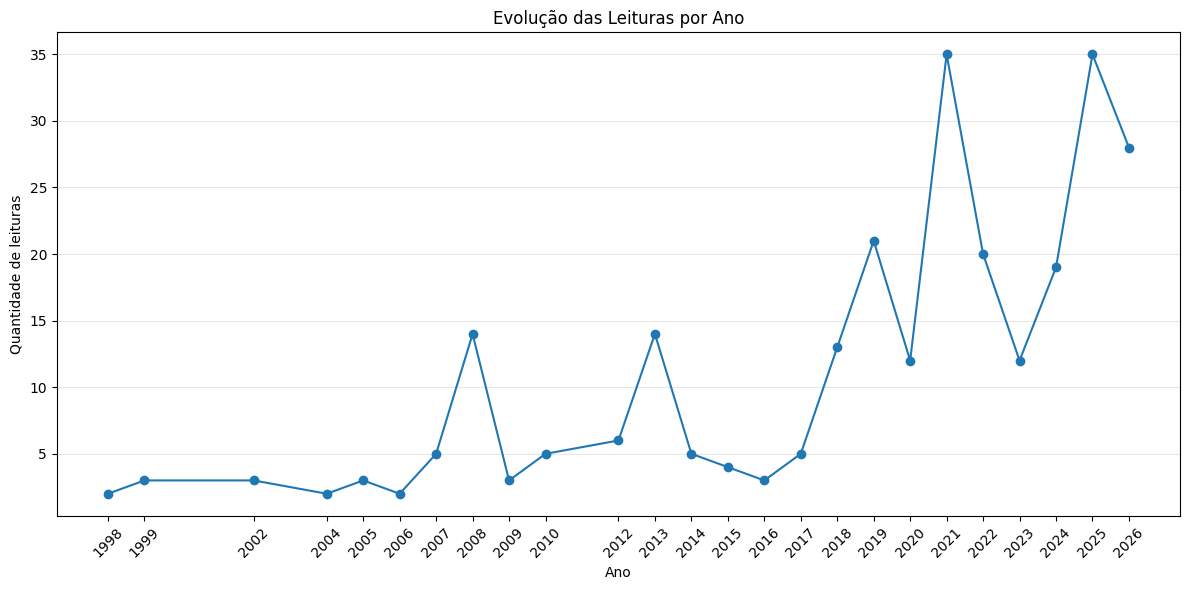

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    leituras_por_ano["Ano"],
    leituras_por_ano["Quantidade"],
    marker="o"
)

plt.title("Evolução das Leituras por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de leituras")
plt.xticks(leituras_por_ano["Ano"], rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

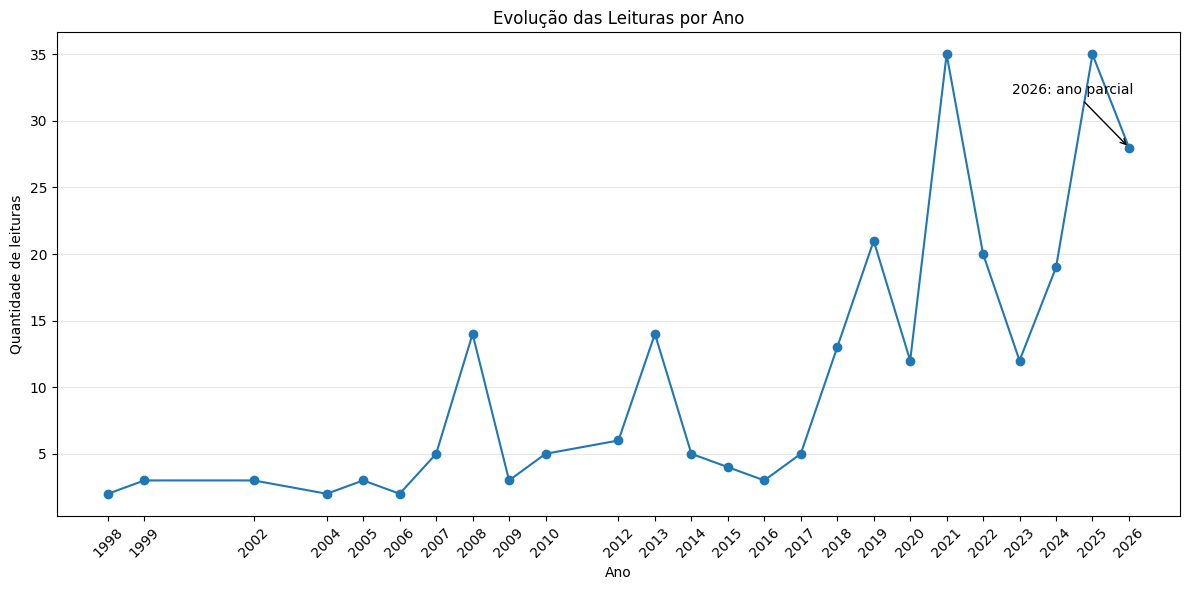

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    leituras_por_ano["Ano"],
    leituras_por_ano["Quantidade"],
    marker="o"
)

plt.title("Evolução das Leituras por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de leituras")
plt.xticks(leituras_por_ano["Ano"], rotation=45)
plt.grid(axis="y", alpha=0.3)

# Identificar 2026 como ano parcial
quantidade_2026 = leituras_por_ano.loc[
    leituras_por_ano["Ano"].eq(2026),
    "Quantidade"
].iloc[0]

plt.annotate(
    "2026: ano parcial",
    xy=(2026, quantidade_2026),
    xytext=(2022.8, quantidade_2026 + 4),
    arrowprops={"arrowstyle": "->"}
)

plt.tight_layout()
plt.show()

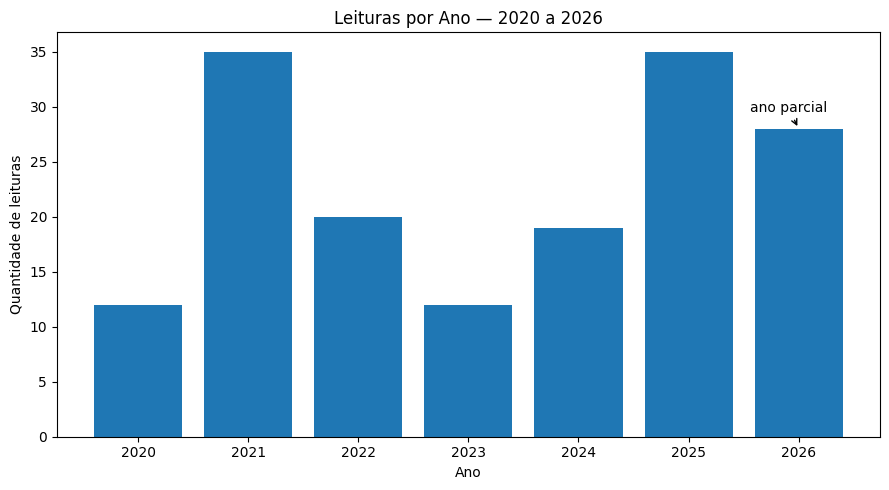

In [50]:
plt.figure(figsize=(9, 5))

plt.bar(
    evolucao_recente["Ano"].astype(str),
    evolucao_recente["Quantidade"]
)

plt.title("Leituras por Ano — 2020 a 2026")
plt.xlabel("Ano")
plt.ylabel("Quantidade de leituras")

# Identificar 2026 como ano parcial
valor_2026 = evolucao_recente.loc[
    evolucao_recente["Ano"].eq(2026),
    "Quantidade"
].iloc[0]

plt.annotate(
    "ano parcial",
    xy=("2026", valor_2026),
    xytext=(-35, 12),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

plt.tight_layout()
plt.show()

In [51]:
# Autores com mais livros na coleção

autores_mais_presentes = (
    livros_tratados["Autor"]
    .value_counts()
    .head(15)
    .rename_axis("Autor")
    .reset_index(name="Quantidade")
)

display(autores_mais_presentes)

,Autor,Quantidade
0,J. K. Rowling,18
1,J. R. R. Tolkien,17
2,Lemony Snicket,13
3,Anônimo,10
4,Rick Riordan,10
5,Roger Zelazny,10
6,Agatha Christie,7
7,Justin Somper,6
8,R. F. Kuang,5
9,Graciliano Ramos,5


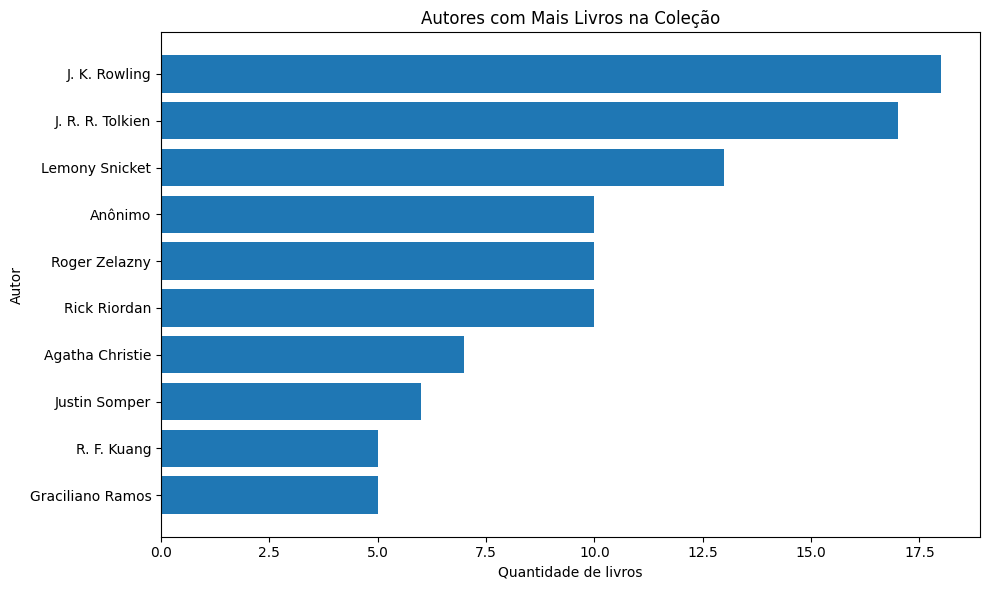

In [52]:
# Gráfico dos 10 autores com mais livros na coleção

top_10_autores = autores_mais_presentes.head(10).sort_values(
    "Quantidade",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_autores["Autor"],
    top_10_autores["Quantidade"]
)

plt.title("Autores com Mais Livros na Coleção")
plt.xlabel("Quantidade de livros")
plt.ylabel("Autor")

plt.tight_layout()
plt.show()

In [53]:
# Editoras com mais livros na coleção

editoras_mais_presentes = (
    livros_tratados["Editora"]
    .value_counts(dropna=False)
    .rename_axis("Editora")
    .reset_index(name="Quantidade")
)

display(editoras_mais_presentes.head(15))

,Editora,Quantidade
0,<NA>,93
1,Clube de Literatura Clássica,37
2,Intrinseca,30
3,Seguinte,16
4,Harper Collins,16
5,Rocco,12
6,Galera,11
7,Principis,10
8,Record,8
9,Darkside,8


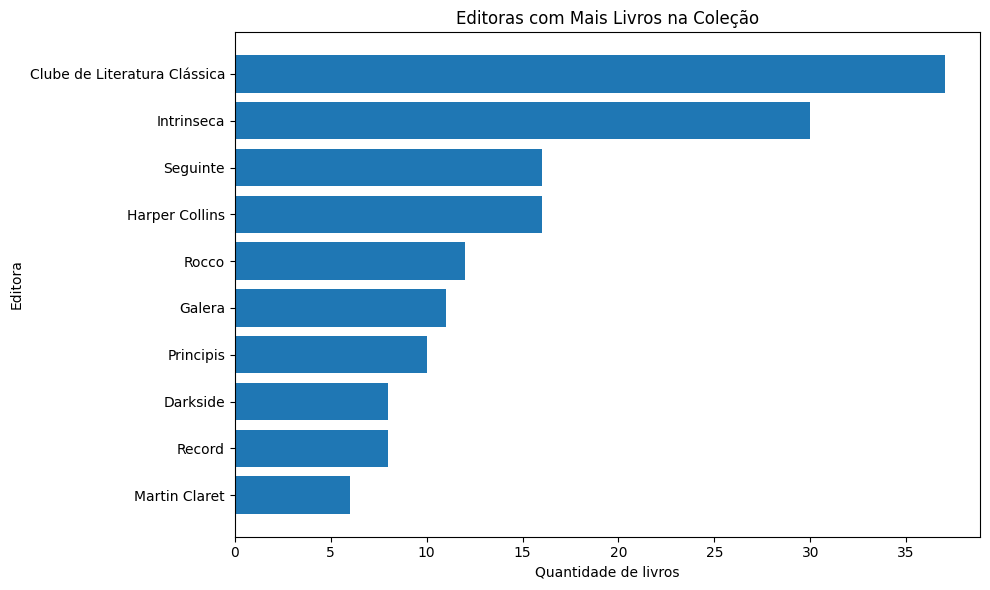

In [54]:
# Gráfico das 10 editoras com mais livros

top_10_editoras = (
    livros_tratados["Editora"]
    .dropna()
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_editoras.index,
    top_10_editoras.values
)

plt.title("Editoras com Mais Livros na Coleção")
plt.xlabel("Quantidade de livros")
plt.ylabel("Editora")

plt.tight_layout()
plt.show()

In [55]:
# Quantidade de livros por ano de compra

compras_por_ano = (
    livros_tratados
    .dropna(subset=["Ano-Compra"])
    .assign(
        Ano_Compra=lambda df: df["Ano-Compra"].astype(int)
    )
    .groupby("Ano_Compra")
    .size()
    .reset_index(name="Quantidade")
    .sort_values("Ano_Compra")
)

display(compras_por_ano)

,Ano_Compra,Quantidade
0,2015,3
1,2018,10
2,2019,2
3,2020,8
4,2022,10
5,2023,45
6,2024,7
7,2025,15
8,2026,76


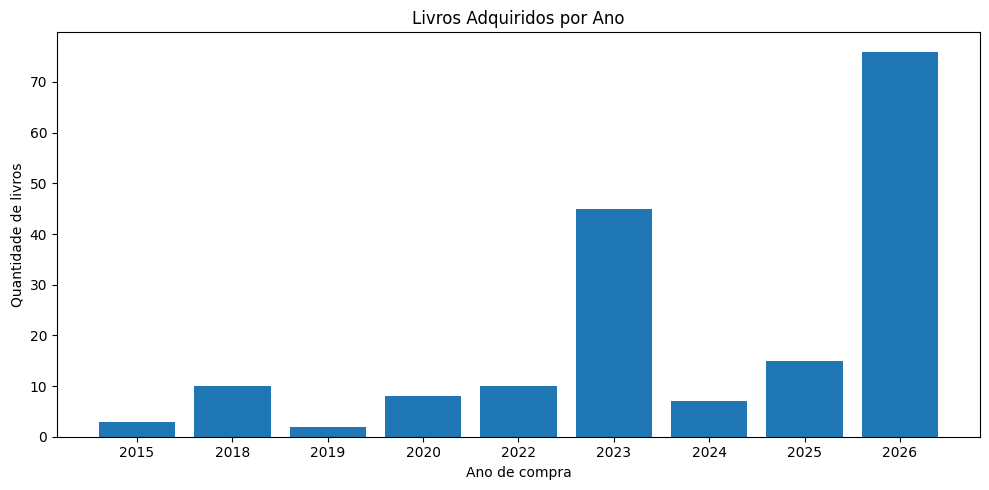

In [56]:
plt.figure(figsize=(10, 5))

plt.bar(
    compras_por_ano["Ano_Compra"].astype(str),
    compras_por_ano["Quantidade"]
)

plt.title("Livros Adquiridos por Ano")
plt.xlabel("Ano de compra")
plt.ylabel("Quantidade de livros")
plt.tight_layout()

plt.show()

In [57]:
total_com_ano = livros_tratados["Ano-Compra"].notna().sum()
total_sem_ano = livros_tratados["Ano-Compra"].isna().sum()

ano_maior_compra = compras_por_ano.loc[
    compras_por_ano["Quantidade"].idxmax()
]

print("Livros com ano de compra:", total_com_ano)
print("Livros sem ano de compra:", total_sem_ano)

print(
    "Percentual com ano preenchido:",
    round(total_com_ano / len(livros_tratados) * 100, 2)
)

print(
    "Percentual sem ano preenchido:",
    round(total_sem_ano / len(livros_tratados) * 100, 2)
)

print(
    "Ano com mais aquisições:",
    int(ano_maior_compra["Ano_Compra"])
)

print(
    "Quantidade no ano de maior aquisição:",
    int(ano_maior_compra["Quantidade"])
)

Livros com ano de compra: 176
Livros sem ano de compra: 149
Percentual com ano preenchido: 54.15
Percentual sem ano preenchido: 45.85
Ano com mais aquisições: 2026
Quantidade no ano de maior aquisição: 76


In [58]:
# Relação entre ano de compra e status de leitura

compras_status = (
    livros_tratados
    .dropna(subset=["Ano-Compra"])
    .assign(
        Ano_Compra=lambda df: df["Ano-Compra"].astype(int)
    )
    .groupby(["Ano_Compra", "Lido"])
    .size()
    .reset_index(name="Quantidade")
    .sort_values(["Ano_Compra", "Lido"])
)

display(compras_status)

,Ano_Compra,Lido,Quantidade
0,2015,Não,2
1,2015,Sim,1
2,2018,Sim,10
3,2019,Sim,2
4,2020,Não,5
5,2020,Sim,3
6,2022,Não,7
7,2022,Sim,3
8,2023,Abandonado,2
9,2023,Não,38


In [59]:
# Tabela dinâmica: status de leitura por ano de compra

status_por_ano_compra = compras_status.pivot(
    index="Ano_Compra",
    columns="Lido",
    values="Quantidade"
).fillna(0).astype(int)

display(status_por_ano_compra)

Lido,Abandonado,Lendo,Não,Relendo,Sim
Ano_Compra,,,,,
2015,0,0,2,0,1
2018,0,0,0,0,10
2019,0,0,0,0,2
2020,0,0,5,0,3
2022,0,0,7,0,3
2023,2,0,38,1,4
2024,0,0,5,0,2
2025,0,1,10,0,4
2026,0,0,61,0,15


In [60]:
# Taxa de livros lidos por ano de compra

taxa_leitura_por_ano = (
    livros_tratados
    .dropna(subset=["Ano-Compra"])
    .assign(
        Ano_Compra=lambda df: df["Ano-Compra"].astype(int),
        Foi_lido=lambda df: df["Lido"].eq("Sim")
    )
    .groupby("Ano_Compra")
    .agg(
        Total=("Nome", "count"),
        Lidos=("Foi_lido", "sum")
    )
    .reset_index()
)

taxa_leitura_por_ano["Taxa de leitura (%)"] = (
    taxa_leitura_por_ano["Lidos"]
    / taxa_leitura_por_ano["Total"]
    * 100
).round(2)

display(taxa_leitura_por_ano)

,Ano_Compra,Total,Lidos,Taxa de leitura (%)
0,2015,3,1,33.33
1,2018,10,10,100.0
2,2019,2,2,100.0
3,2020,8,3,37.5
4,2022,10,3,30.0
5,2023,45,4,8.89
6,2024,7,2,28.57
7,2025,15,4,26.67
8,2026,76,15,19.74


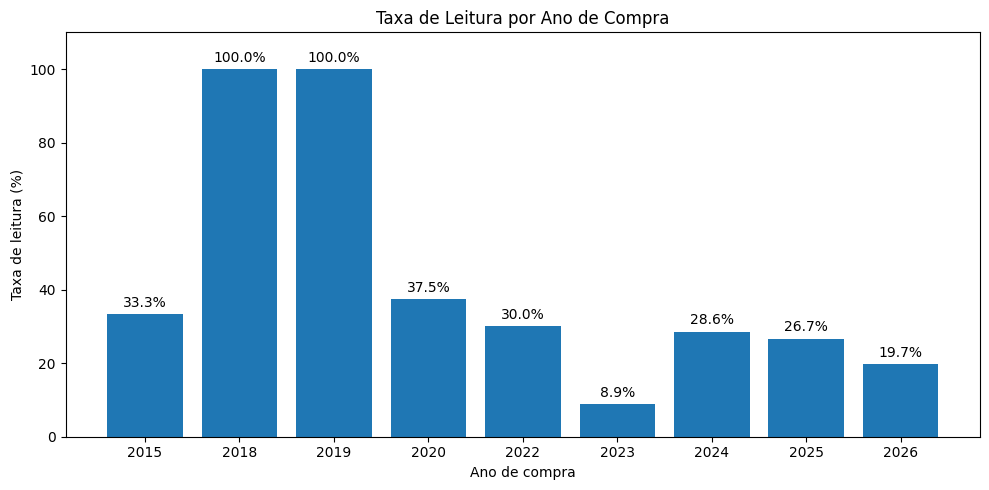

In [61]:
plt.figure(figsize=(10, 5))

plt.bar(
    taxa_leitura_por_ano["Ano_Compra"].astype(str),
    taxa_leitura_por_ano["Taxa de leitura (%)"]
)

plt.title("Taxa de Leitura por Ano de Compra")
plt.xlabel("Ano de compra")
plt.ylabel("Taxa de leitura (%)")
plt.ylim(0, 110)

for indice, linha in taxa_leitura_por_ano.iterrows():
    plt.text(
        str(int(linha["Ano_Compra"])),
        linha["Taxa de leitura (%)"] + 2,
        f'{linha["Taxa de leitura (%)"]:.1f}%',
        ha="center"
    )

plt.tight_layout()
plt.show()

In [62]:
# Distribuição das leituras por formato ou plataforma

formatos_leitura = (
    lidos_tratados["Formato_ou_Plataforma"]
    .fillna("Não informado / físico")
    .value_counts()
    .rename_axis("Formato ou plataforma")
    .reset_index(name="Quantidade")
)

formatos_leitura["Percentual"] = (
    formatos_leitura["Quantidade"]
    / len(lidos_tratados)
    * 100
).round(2)

display(formatos_leitura)

,Formato ou plataforma,Quantidade,Percentual
0,Não informado / físico,223,81.09
1,Audible,25,9.09
2,Kindle,20,7.27
3,Internet,4,1.45
4,Youtube,2,0.73
5,Spotify,1,0.36


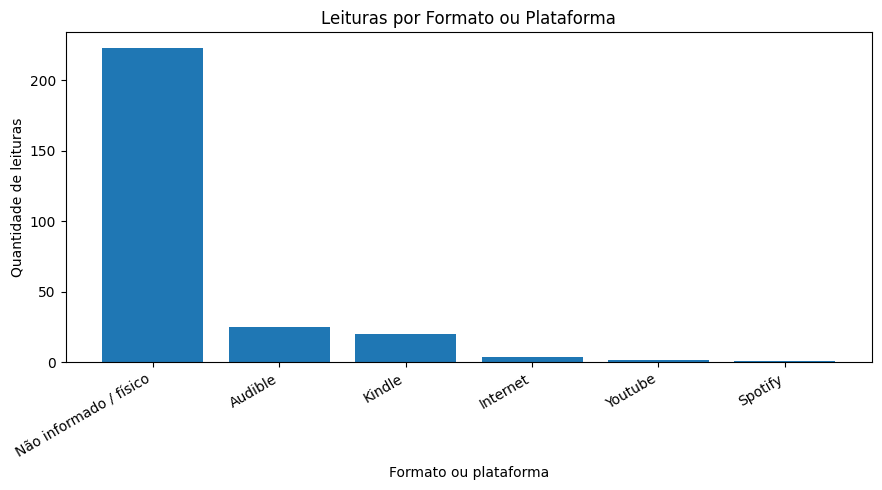

In [63]:
plt.figure(figsize=(9, 5))

plt.bar(
    formatos_leitura["Formato ou plataforma"],
    formatos_leitura["Quantidade"]
)

plt.title("Leituras por Formato ou Plataforma")
plt.xlabel("Formato ou plataforma")
plt.ylabel("Quantidade de leituras")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [64]:
# Livros emprestados por pessoa

emprestimos_por_pessoa = (
    lidos_tratados["Emprestado_para"]
    .dropna()
    .value_counts()
    .rename_axis("Pessoa")
    .reset_index(name="Quantidade")
)

display(emprestimos_por_pessoa)

,Pessoa,Quantidade
0,Plínio,17
1,Larissa,17
2,Amanda,17
3,Maris,4
4,Bibliotecaria,4
5,Aluna,3
6,Lorena,3
7,Helena,1
8,Prof Uruguai,1
9,Miguel,1


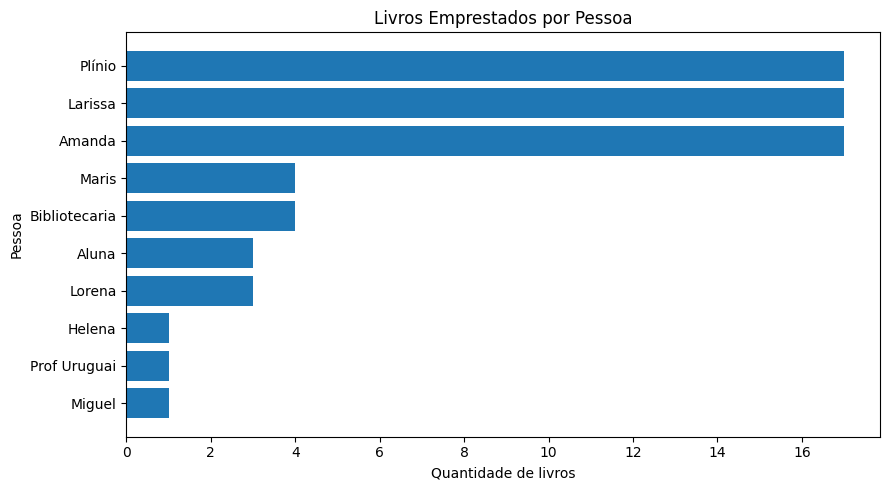

In [65]:
plt.figure(figsize=(9, 5))

plt.barh(
    emprestimos_por_pessoa["Pessoa"][::-1],
    emprestimos_por_pessoa["Quantidade"][::-1]
)

plt.title("Livros Emprestados por Pessoa")
plt.xlabel("Quantidade de livros")
plt.ylabel("Pessoa")

plt.tight_layout()
plt.show()

In [66]:
# Corrigir o nome da coluna conforme o significado real dos dados

lidos_tratados = lidos_tratados.rename(
    columns={"Emprestado_para": "Emprestado_de"}
)

print(lidos_tratados.columns.tolist())

display(
    lidos_tratados[
        lidos_tratados["Emprestado_de"].notna()
    ][
        [
            "Nome",
            "Status na Estante",
            "Detalhe",
            "Emprestado_de"
        ]
    ].head(20)
)

['Nome', 'Autor', 'Data de Leitura', 'Status na Estante', 'Detalhe', 'Formato_ou_Plataforma', 'Emprestado_de', 'Origem_ou_Instituição']


,Nome,Status na Estante,Detalhe,Emprestado_de
8,Harry Potter e a Pedra Filosofal,Emprestado,Plínio,Plínio
9,Harry Potter e a Câmara Secreta,Emprestado,Plínio,Plínio
11,Harry Potter e o Prisioneiro de Azkaban,Emprestado,Plínio,Plínio
12,Brida,Emprestado,Larissa,Larissa
13,Ciclo de Avalon - As Brumas de Avalon - A Senh...,Emprestado,Larissa,Larissa
14,Ciclo de Avalon - As Brumas de Avalon - A Gran...,Emprestado,Larissa,Larissa
15,Harry Potter e o Cálice de Fogo,Emprestado,Plínio,Plínio
16,Harry Potter e a Ordem da Fênix,Emprestado,Plínio,Plínio
17,Harry Potter e o Enigma do Príncipe,Emprestado,Plínio,Plínio
18,Ciclo de Avalon - As Brumas de Avalon - O Pris...,Emprestado,Larissa,Larissa


,Emprestado por,Quantidade
0,Plínio,17
1,Larissa,17
2,Amanda,17
3,Maris,4
4,Bibliotecaria,4
5,Aluna,3
6,Lorena,3
7,Helena,1
8,Prof Uruguai,1
9,Miguel,1


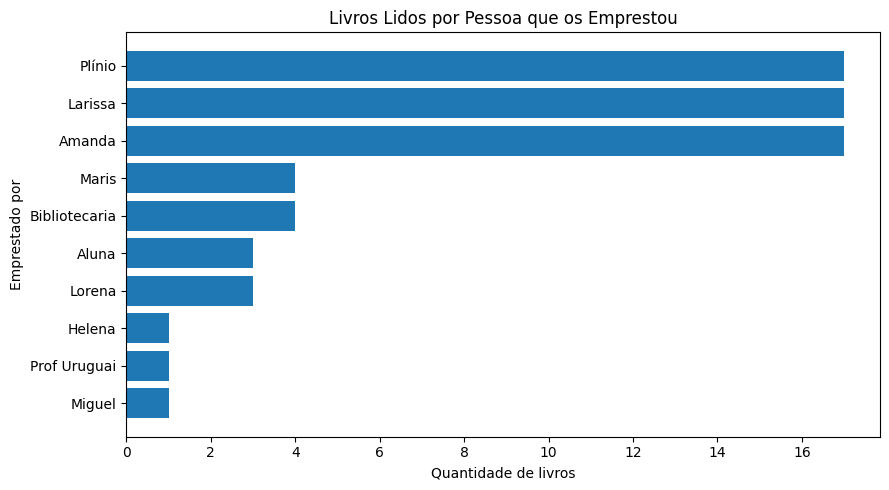

In [67]:
# Livros lidos por pessoa que os emprestou

emprestimos_por_pessoa = (
    lidos_tratados["Emprestado_de"]
    .dropna()
    .value_counts()
    .rename_axis("Emprestado por")
    .reset_index(name="Quantidade")
)

display(emprestimos_por_pessoa)

plt.figure(figsize=(9, 5))

plt.barh(
    emprestimos_por_pessoa["Emprestado por"][::-1],
    emprestimos_por_pessoa["Quantidade"][::-1]
)

plt.title("Livros Lidos por Pessoa que os Emprestou")
plt.xlabel("Quantidade de livros")
plt.ylabel("Emprestado por")

plt.tight_layout()
plt.show()

In [68]:
origens_leitura = (
    lidos_tratados["Origem_ou_Instituição"]
    .dropna()
    .value_counts()
    .rename_axis("Origem ou instituição")
    .reset_index(name="Quantidade")
)

display(origens_leitura)

,Origem ou instituição,Quantidade
0,Sesc,4
1,Irradiação,3
2,UEG,2
3,IFG,1


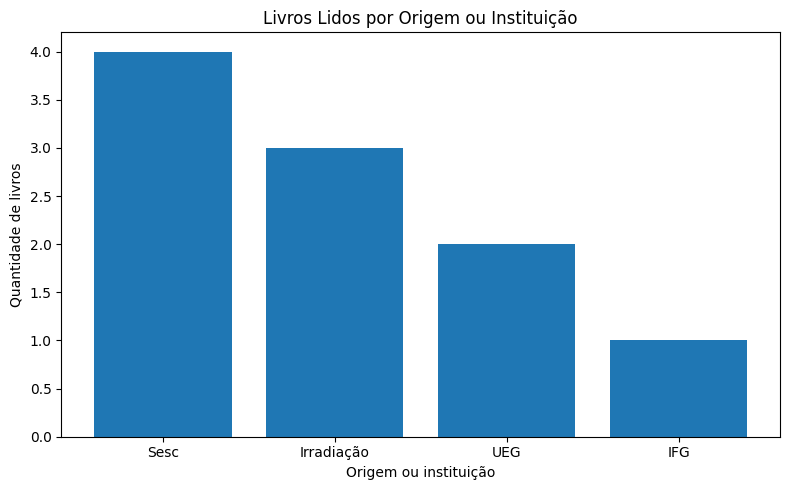

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    origens_leitura["Origem ou instituição"],
    origens_leitura["Quantidade"]
)

plt.title("Livros Lidos por Origem ou Instituição")
plt.xlabel("Origem ou instituição")
plt.ylabel("Quantidade de livros")

plt.tight_layout()
plt.show()

In [70]:
status_historico = (
    lidos_tratados["Status na Estante"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Quantidade")
)

status_historico["Percentual"] = (
    status_historico["Quantidade"]
    / len(lidos_tratados)
    * 100
).round(2)

display(status_historico)

,Status,Quantidade,Percentual
0,Estante,109,39.64
1,Emprestado,68,24.73
2,Biblioteca,61,22.18
3,Doado,14,5.09
4,A venda,11,4.0
5,Sumiu,10,3.64
6,Vendido,2,0.73


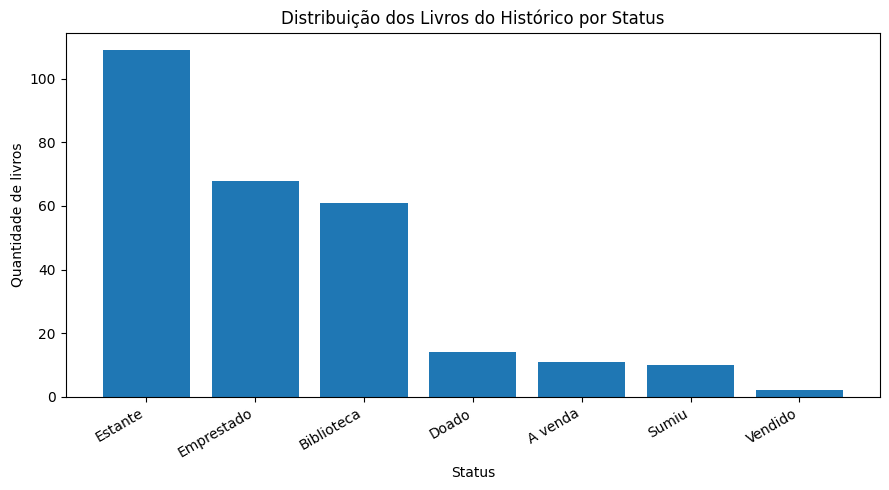

In [71]:
plt.figure(figsize=(9, 5))

plt.bar(
    status_historico["Status"],
    status_historico["Quantidade"]
)

plt.title("Distribuição dos Livros do Histórico por Status")
plt.xlabel("Status")
plt.ylabel("Quantidade de livros")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [72]:
# Resumo dos principais indicadores da análise exploratória

resumo_analise = pd.DataFrame([
    {
        "Indicador": "Livros cadastrados",
        "Resultado": 325,
        "Observação": "Total da coleção tratada"
    },
    {
        "Indicador": "Livros lidos",
        "Resultado": 119,
        "Observação": "36,62% da coleção"
    },
    {
        "Indicador": "Livros não lidos",
        "Resultado": 190,
        "Observação": "58,46% da coleção"
    },
    {
        "Indicador": "Registros no histórico",
        "Resultado": 275,
        "Observação": "274 com data e 1 sem data"
    },
    {
        "Indicador": "Anos recordistas de leitura",
        "Resultado": "2021 e 2025",
        "Observação": "35 leituras em cada ano"
    },
    {
        "Indicador": "Leituras em 2026",
        "Resultado": 28,
        "Observação": "Ano ainda parcial"
    },
    {
        "Indicador": "Autor mais presente",
        "Resultado": "J. K. Rowling",
        "Observação": "18 livros"
    },
    {
        "Indicador": "Editora mais presente",
        "Resultado": "Clube de Literatura Clássica",
        "Observação": "37 livros"
    },
    {
        "Indicador": "Livros sem editora",
        "Resultado": 93,
        "Observação": "28,62% da coleção"
    },
    {
        "Indicador": "Livros com ano de compra",
        "Resultado": 176,
        "Observação": "54,15% da coleção"
    },
    {
        "Indicador": "Ano com mais aquisições",
        "Resultado": 2026,
        "Observação": "76 livros"
    },
    {
        "Indicador": "Menor taxa de leitura por ano de compra",
        "Resultado": "2023",
        "Observação": "8,89%"
    },
    {
        "Indicador": "Leituras por Audible",
        "Resultado": 25,
        "Observação": "9,09% do histórico"
    },
    {
        "Indicador": "Leituras por Kindle",
        "Resultado": 20,
        "Observação": "7,27% do histórico"
    },
    {
        "Indicador": "Livros lidos emprestados por pessoas",
        "Resultado": 68,
        "Observação": "24,73% do histórico"
    },
    {
        "Indicador": "Livros lidos por bibliotecas ou fontes externas",
        "Resultado": 61,
        "Observação": "22,18% do histórico"
    }
])

display(resumo_analise)

,Indicador,Resultado,Observação
0,Livros cadastrados,325,Total da coleção tratada
1,Livros lidos,119,"36,62% da coleção"
2,Livros não lidos,190,"58,46% da coleção"
3,Registros no histórico,275,274 com data e 1 sem data
4,Anos recordistas de leitura,2021 e 2025,35 leituras em cada ano
5,Leituras em 2026,28,Ano ainda parcial
6,Autor mais presente,J. K. Rowling,18 livros
7,Editora mais presente,Clube de Literatura Clássica,37 livros
8,Livros sem editora,93,"28,62% da coleção"
9,Livros com ano de compra,176,"54,15% da coleção"


# Conclusão da Análise Exploratória

A base de dados da Biblioteca Inteligente com IA foi auditada, tratada e analisada no Google Colab.

## Entregas concluídas

- Auditoria das abas principais.
- Remoção de linhas residuais.
- Padronização de campos.
- Correção de inconsistências confirmadas.
- Conciliação entre coleção e histórico de leitura.
- Criação de indicadores e tabelas analíticas.
- Geração de gráficos exploratórios.
- Exportação da base tratada.

## Principais resultados

- 325 livros cadastrados.
- 119 livros lidos.
- 190 livros não lidos.
- 275 registros no histórico de leitura.
- 2021 e 2025 foram os anos com mais leituras.
- 2026 possui 28 leituras registradas até o momento.
- 93 livros estão sem editora cadastrada.
- 149 livros estão sem ano de compra.
- 2026 concentra 76 aquisições registradas.

## Próxima etapa

Enviar a base tratada e os resultados consolidados ao Manus para criação do dashboard funcional.

In [73]:
# Exportar a base tratada com todas as tabelas da análise exploratória

nome_arquivo_analise = "Biblioteca_Inteligente_IA_Analise_Exploratoria.xlsx"

with pd.ExcelWriter(
    nome_arquivo_analise,
    engine="openpyxl"
) as writer:

    # Bases principais
    livros_tratados.to_excel(
        writer,
        sheet_name="Livros na Estante",
        index=False
    )

    lidos_tratados.to_excel(
        writer,
        sheet_name="Lidos",
        index=False
    )

    # Auditoria e conciliação
    achados_auditoria.to_excel(
        writer,
        sheet_name="Auditoria",
        index=False
    )

    candidatos_correspondencia.to_excel(
        writer,
        sheet_name="Conciliação",
        index=False
    )

    # Resumo e indicadores
    resumo_analise.to_excel(
        writer,
        sheet_name="Resumo",
        index=False
    )

    estatisticas_leitura_tratadas.to_excel(
        writer,
        sheet_name="Status de Leitura",
        index=False
    )

    # Tabelas analíticas
    leituras_por_ano.to_excel(
        writer,
        sheet_name="Leituras por Ano",
        index=False
    )

    autores_mais_presentes.to_excel(
        writer,
        sheet_name="Autores",
        index=False
    )

    editoras_mais_presentes.to_excel(
        writer,
        sheet_name="Editoras",
        index=False
    )

    compras_por_ano.to_excel(
        writer,
        sheet_name="Compras por Ano",
        index=False
    )

    taxa_leitura_por_ano.to_excel(
        writer,
        sheet_name="Taxa de Leitura",
        index=False
    )

    formatos_leitura.to_excel(
        writer,
        sheet_name="Formatos",
        index=False
    )

    emprestimos_por_pessoa.to_excel(
        writer,
        sheet_name="Emprestado de",
        index=False
    )

    origens_leitura.to_excel(
        writer,
        sheet_name="Origens",
        index=False
    )

    status_historico.to_excel(
        writer,
        sheet_name="Status Histórico",
        index=False
    )

print("Arquivo criado com sucesso:")
print(nome_arquivo_analise)

Arquivo criado com sucesso:
Biblioteca_Inteligente_IA_Analise_Exploratoria.xlsx


In [74]:
import os

print(
    "Arquivo encontrado:",
    os.path.exists(
        "Biblioteca_Inteligente_IA_Analise_Exploratoria.xlsx"
    )
)

print(
    "Tamanho do arquivo:",
    os.path.getsize(
        "Biblioteca_Inteligente_IA_Analise_Exploratoria.xlsx"
    ),
    "bytes"
)

Arquivo encontrado: True
Tamanho do arquivo: 51056 bytes


In [75]:
from google.colab import files

files.download(
    "Biblioteca_Inteligente_IA_Analise_Exploratoria.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>